# 12 — Tiny Ridge + inverse QSVT + interferometric classical shadows

这个 notebook 把三件过去尚未实现的事情接成一条可以上 Quafu-SQC 真机的
**tiny 机制验证链**：

$$
\text{official IMDb train}
\longrightarrow
\text{2-dimensional Ridge}
\longrightarrow
\text{inverse QSVT}
\longrightarrow
|\widetilde w\rangle
\longrightarrow
\text{global-Clifford shadows}
\longrightarrow
\text{held-out classification}.
$$

它同时给出一个受论文 Figure 2 启发、但使用本项目无泄漏 held-out 数据的
machine-size–accuracy 重新记账，并把真正的 tiny hardware bridge 放在
**独立面板**，避免把不同资源口径画成可直接比较的同一纵轴。

> **科学边界**
>
> 论文 Figure 2 的三条曲线共享同一组经典 `RidgeClassifier` accuracy；
> 三者只替换纵轴的解析机器大小。官方真实数据脚本没有运行 QOS、QSVT 或
> classical shadows。因此本 notebook 严格区分：
>
> 1. `paper-style accounting`：经典 held-out accuracy + 理论内存公式；
> 2. `tiny hardware bridge`：真正执行 2×2 Ridge inverse QSVT 和
>    interferometric shadow；
> 3. 未实现的 scalable end-to-end QOS data loading。
>
> tiny 线路使用训练集学到的监督式词汇投影把 IMDb 压到两个特征。它能得到
> 有意义的 held-out accuracy，但这个经典投影的存储不能冒充免费 QRAM/QOS，
> 所以低 qubit 点本身不是指数优势证据。

论文对应关系：

- Ridge 解：

$$
w=(X^\top X/N+\lambda I)^{-1}X^\top y/N.
$$

- 本 notebook 的 tiny inverse QSVT 是 normal-equation 版本；它与
  论文在奇异值上使用
  $g(\sigma)=\sigma/(\sigma^2+\lambda)$ 得到同一 Ridge 方向，但不是
  可扩展 sparse-oracle 实现。
- 干涉式 shadow 使用论文 Lemma F.16：

$$
|\widetilde w\rangle=
\frac{|0\rangle|0\rangle+|1\rangle|w\rangle}{\sqrt 2},
\qquad
\operatorname{tr}(\rho_{\widetilde w}O_x)
=\operatorname{Re}\langle x|w\rangle.
$$

源码依据：

- [论文 Appendix A 与 Theorem F.13–F.16](https://arxiv.org/pdf/2604.07639)
- [固定源码的 IMDb Ridge 路径](https://github.com/haimengzhao/quantum-oracle-sketching/blob/10c092cefcfdff9951bf5729bd2ffb4c25fe2254/real_datasets/imdb_svm.py)
- [固定源码的 inverse-QSVT utilities](https://github.com/haimengzhao/quantum-oracle-sketching/blob/10c092cefcfdff9951bf5729bd2ffb4c25fe2254/qsvt.py)


In [1]:
# ========================= 用户配置区 =========================
# 安全默认值：只运行离线准备、验证、理想模拟和绘图。
ACTION = "dry_run"  # dry_run | status | submit | fetch

BACKEND = "Baihua"
BITSTRING_ORDER = "qiskit"  # 若 one-hot 校准相反，改成 "reversed"

# submit 时按阶段和批次选任务。每次默认最多 2 条，避免误提交整套 shadows。
RUN_STAGE = "calibration"  # calibration | ridge | shadow_control | shadow_qsvt
BATCH_START = 0
BATCH_SIZE = 2
MAX_TASKS_PER_SUBMISSION_CELL = 2
CONFIRM_REAL_SUBMISSION = ""

# full shadow 是 4-qubit、dense-resynthesized、约百个 CX 的实验。
# 只有 calibration、ridge 和 shadow_control 都可接受后才改成 True。
ALLOW_FULL_QSVT_SHADOW_SUBMISSION = False
ALLOW_DUPLICATE_SUBMISSION = False
REQUIRE_FIXED_LAYOUT_FOR_FULL_SHADOW = True

DEFAULT_COMPILER = "quarkcircuit"
ALLOWED_COMPILERS = {"quarkcircuit", "qsteed"}
# Corrected quasi-counts 不使用二项 Wilson 区间；本 notebook 暂时强制 False。
USE_READOUT_CORRECTION = False
OPEN_DD = None
# 完整 hardware chain 应从平台拓扑选择同一组连通物理 qubits。
TARGET_QUBITS = []
# full 阶段必须显式冻结同一设备时间窗内的 prerequisite task cohort。
# 最终图还要把 12 条 full-QSVT task ids 一并加入该列表。
HARDWARE_COHORT_TASK_IDS = []
CONFIRM_COHERENT_HARDWARE_COHORT = ""
# 以下是保守的实验发布门槛，不是论文中的复杂度定理。
MIN_CALIBRATION_EXPECTED_WILSON_LOWER = 0.50
MIN_RIDGE_HERALD_WILSON_LOWER = 0.02
MIN_RIDGE_VERIFIER_WILSON_LOWER = 0.50
MIN_SHADOW_CONTROL_HERALD_WILSON_LOWER = 0.75
MIN_SHADOW_CONTROL_COSINE_BOOTSTRAP_LOWER = 0.50
MAX_SHADOW_CONTROL_SIGNED_OVERLAP_RMSE = 0.50
MIN_SHADOW_CONTROL_ACCURACY_BOOTSTRAP_LOWER = 0.70

# Quafu 每个静态 Clifford setting 使用一条任务；同一 setting 内重复 shots。
SHOTS = 2048
N_SHADOW_SETTINGS = 12
SHADOW_SEED = 20260729

# fetch 可取 registry 中全部任务，或填具体 run_label。
FETCH_RUN_LABELS = ["*"]
MANUAL_FETCH_PLAN = []
FORCE_FETCH_NONFINISHED = False
RESULT_TIMEOUT_SECONDS = 120

# IMDb tiny 模型：K 个正向词 + K 个负向词聚合为两个特征。
K_CANDIDATES = [16, 32, 64, 128, 256]
RIDGE_LAMBDA = 0.05  # 对平均平方损失的正则强度
VALIDATION_SEED = 20260729
POLYNOMIAL_BOUND = 0.80

# 本地验证。
RUN_LOCAL_IDEAL_SHOTS = True
LOCAL_SIMULATOR_SEED = 20260729
BOOTSTRAP_REPEATS = 400


In [2]:
import hashlib
import json
import os
import platform
import re
from datetime import datetime, timezone
from getpass import getpass
from pathlib import Path

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
import pyqsp
import qiskit
from pyqsp import angle_sequence
from qiskit import QuantumCircuit, qasm2, transpile
from qiskit.circuit.library import StatePreparation, UnitaryGate
from qiskit.quantum_info import Operator, Statevector, random_clifford
from qiskit_aer import AerSimulator
from scipy.linalg import sqrtm
from sklearn import __version__ as sklearn_version
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


def resolve_project_root():
    starts = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for start in starts:
        for candidate in [start, *start.parents]:
            if (
                (candidate / "notebooks").is_dir()
                and (candidate / "results").is_dir()
                and (candidate / "README.md").exists()
            ):
                return candidate.resolve()
    raise FileNotFoundError("无法自动定位 Quafu 项目根目录。")


PROJECT_ROOT = resolve_project_root()
RESULT_DIR = PROJECT_ROOT / "results" / "tiny_ridge_qsvt_shadows"
QASM_DIR = RESULT_DIR / "qasm"
RAW_DIR = RESULT_DIR / "raw_results"
FIGURE_DIR = PROJECT_ROOT / "assets" / "figures"
CIRCUIT_DIR = PROJECT_ROOT / "assets" / "circuits"
for directory in [RESULT_DIR, QASM_DIR, FIGURE_DIR, CIRCUIT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

CACHE_PATH = RESULT_DIR / "tiny_imdb_projection.npz"
DATA_SUMMARY_PATH = RESULT_DIR / "tiny_imdb_projection.json"
MODEL_PATH = RESULT_DIR / "tiny_ridge_qsvt_model.json"
MANIFEST_PATH = RESULT_DIR / "manifest.json"
MANIFEST_CSV_PATH = RESULT_DIR / "manifest.csv"
LOCAL_COUNTS_PATH = RESULT_DIR / "local_ideal_counts.json"
LOCAL_SUMMARY_PATH = RESULT_DIR / "local_ideal_summary.json"
REGISTRY_PATH = RESULT_DIR / "task_registry.json"
HARDWARE_JSON_PATH = RESULT_DIR / "hardware_results.json"
HARDWARE_CSV_PATH = RESULT_DIR / "hardware_results.csv"


def json_default(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, complex):
        return {"real": value.real, "imag": value.imag}
    if isinstance(value, Path):
        return str(value)
    raise TypeError(f"Cannot JSON-encode {type(value).__name__}")


def write_json_atomic(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(
        json.dumps(
            payload,
            ensure_ascii=False,
            indent=2,
            default=json_default,
        )
        + "\n",
        encoding="utf-8",
    )
    temporary.replace(path)


def sha256_text(text):
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


def canonical_json_hash(payload):
    return sha256_text(
        json.dumps(
            payload,
            ensure_ascii=False,
            sort_keys=True,
            separators=(",", ":"),
            default=json_default,
        )
    )


def sha256_array(array):
    array = np.ascontiguousarray(array)
    payload = (
        str(array.dtype).encode()
        + repr(array.shape).encode()
        + array.tobytes()
    )
    return hashlib.sha256(payload).hexdigest()


ENVIRONMENT = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn_version,
    "qiskit": qiskit.__version__,
    "pyqsp": getattr(pyqsp, "__version__", "0.2.0"),
}

assert ACTION in {"dry_run", "status", "submit", "fetch"}
assert BITSTRING_ORDER in {"qiskit", "reversed"}
assert RUN_STAGE in {"calibration", "ridge", "shadow_control", "shadow_qsvt"}
assert isinstance(BATCH_START, int) and not isinstance(BATCH_START, bool)
assert int(BATCH_START) >= 0
assert isinstance(BATCH_SIZE, int) and not isinstance(BATCH_SIZE, bool)
assert 1 <= int(BATCH_SIZE) <= int(MAX_TASKS_PER_SUBMISSION_CELL)
assert isinstance(SHOTS, int) and not isinstance(SHOTS, bool)
assert int(N_SHADOW_SETTINGS) >= 4
assert int(SHOTS) > 0 and int(SHOTS) % 1024 == 0
assert OPEN_DD in {None, "XY4", "CPMG"}
assert all(
    isinstance(item, int)
    and not isinstance(item, bool)
    and item > 0
    for item in HARDWARE_COHORT_TASK_IDS
)
assert len(HARDWARE_COHORT_TASK_IDS) == len(
    set(HARDWARE_COHORT_TASK_IDS)
)
assert isinstance(CONFIRM_COHERENT_HARDWARE_COHORT, str)
assert 0.0 <= MIN_CALIBRATION_EXPECTED_WILSON_LOWER <= 1.0
assert 0.0 <= MIN_RIDGE_HERALD_WILSON_LOWER <= 1.0
assert 0.0 <= MIN_RIDGE_VERIFIER_WILSON_LOWER <= 1.0
assert 0.0 <= MIN_SHADOW_CONTROL_HERALD_WILSON_LOWER <= 1.0
assert -1.0 <= MIN_SHADOW_CONTROL_COSINE_BOOTSTRAP_LOWER <= 1.0
assert MAX_SHADOW_CONTROL_SIGNED_OVERLAP_RMSE > 0.0
assert 0.0 <= MIN_SHADOW_CONTROL_ACCURACY_BOOTSTRAP_LOWER <= 1.0
print("Project root:", PROJECT_ROOT)
print("Environment:", ENVIRONMENT)


Matplotlib is building the font cache; this may take a moment.


Project root: /Users/tangzhi/.codex/.chatgpt-projects/g-p-6a5f771ad30c8191a3fc5b9cc6ea6d75/Quafu_stage
Environment: {'python': '3.13.7', 'numpy': '2.3.3', 'pandas': '2.3.2', 'scikit_learn': '1.9.0', 'qiskit': '2.5.1', 'pyqsp': '0.2.0'}


## 1. Leakage-safe tiny IMDb projection

为了让 1 个 system qubit 仍有可辨认的分类信号，训练集内部先学习一个词汇方向，
再把评论压成两个实特征：

$$
z_+(x)=\sum_{j\in V_+}\operatorname{tfidf}_j(x),
\qquad
z_-(x)=\sum_{j\in V_-}\operatorname{tfidf}_j(x).
$$

其中 $V_+$ 和 $V_-$ 只由 official train 决定：

1. official train 内部固定拆成 fit/validation；
2. 在 fit 上学习候选词方向；
3. 只用 validation 选择 $K$；
4. 固定 $K$ 后用完整 official train 重学词表并拟合 tiny Ridge；
5. official test 仅作最终评估。

首次运行会从本机 IMDb 目录生成一个不含原始文本的派生缓存；以后以及 GitHub
clone 可以直接读取该缓存。监督式词汇表属于经典预处理状态，后面不会把它当作
免费的量子内存。


In [3]:
def find_imdb_root():
    candidates = []
    if os.environ.get("IMDB_DATA_ROOT"):
        candidates.append(Path(os.environ["IMDB_DATA_ROOT"]))
    candidates.extend(
        [
            Path("/private/tmp/qos-imdb-data/aclImdb"),
            Path.home() / "Downloads" / "aclImdb",
            PROJECT_ROOT / "data" / "aclImdb",
        ]
    )
    for candidate in candidates:
        if (
            (candidate / "train" / "pos").is_dir()
            and (candidate / "train" / "neg").is_dir()
            and (candidate / "test" / "pos").is_dir()
            and (candidate / "test" / "neg").is_dir()
        ):
            return candidate.resolve()
    return None


def load_imdb_split(root, split):
    texts, labels, relative_paths = [], [], []
    for label_name, label in [("neg", -1), ("pos", 1)]:
        for path in sorted((root / split / label_name).glob("*.txt")):
            texts.append(path.read_text(encoding="utf-8"))
            labels.append(label)
            relative_paths.append(str(path.relative_to(root)))
    return texts, np.asarray(labels, dtype=np.int8), relative_paths


def ordered_extreme_terms(terms, weights, k):
    positive = np.argpartition(weights, -k)[-k:]
    negative = np.argpartition(weights, k)[:k]
    positive = positive[np.argsort(weights[positive])[::-1]]
    negative = negative[np.argsort(weights[negative])]
    return terms[positive], terms[negative]


def tiny_features(texts, vectorizer, k):
    matrix = vectorizer.transform(texts)
    return np.column_stack(
        [
            np.asarray(matrix[:, :k].sum(axis=1)).ravel(),
            np.asarray(matrix[:, k:].sum(axis=1)).ravel(),
        ]
    )


def solve_tiny_ridge(z_train, y_train, ridge_lambda):
    n = len(y_train)
    matrix = z_train.T @ z_train / n + ridge_lambda * np.eye(2)
    rhs = z_train.T @ y_train.astype(float) / n
    weight = np.linalg.solve(matrix, rhs)
    return matrix, rhs, weight


def build_tiny_imdb_cache():
    imdb_root = find_imdb_root()
    if imdb_root is None:
        raise FileNotFoundError(
            "缺少派生缓存，也找不到 aclImdb。请设置 IMDB_DATA_ROOT。"
        )

    train_texts, y_train, train_paths = load_imdb_split(
        imdb_root, "train"
    )
    test_texts, y_test, test_paths = load_imdb_split(
        imdb_root, "test"
    )
    assert len(train_texts) == len(test_texts) == 25000
    assert np.sum(y_train == 1) == np.sum(y_train == -1) == 12500
    assert np.sum(y_test == 1) == np.sum(y_test == -1) == 12500
    assert set(train_paths).isdisjoint(test_paths)

    indices = np.arange(len(y_train))
    fit_idx, validation_idx = train_test_split(
        indices,
        test_size=0.2,
        random_state=int(VALIDATION_SEED),
        stratify=y_train,
    )
    fit_texts = [train_texts[index] for index in fit_idx]
    validation_texts = [train_texts[index] for index in validation_idx]

    selector = TfidfVectorizer(
        max_features=32768,
        min_df=2,
        stop_words="english",
        sublinear_tf=True,
        dtype=np.float64,
    )
    selector_fit = selector.fit_transform(fit_texts)
    selector_model = RidgeClassifier(
        alpha=10.0,
        fit_intercept=True,
        solver="lsqr",
    )
    selector_model.fit(selector_fit, y_train[fit_idx])
    selector_terms = np.asarray(selector.get_feature_names_out())
    selector_weights = np.asarray(selector_model.coef_).ravel()

    validation_rows = []
    for k in K_CANDIDATES:
        positive_terms, negative_terms = ordered_extreme_terms(
            selector_terms, selector_weights, int(k)
        )
        vocabulary_terms = np.concatenate(
            [positive_terms, negative_terms]
        )
        vocabulary = {
            term: index
            for index, term in enumerate(vocabulary_terms.tolist())
        }
        small_vectorizer = TfidfVectorizer(
            vocabulary=vocabulary,
            stop_words="english",
            sublinear_tf=True,
            dtype=np.float64,
        )
        fit_matrix = small_vectorizer.fit_transform(fit_texts)
        validation_matrix = small_vectorizer.transform(validation_texts)
        z_fit_raw = np.column_stack(
            [
                np.asarray(fit_matrix[:, :k].sum(axis=1)).ravel(),
                np.asarray(fit_matrix[:, k:].sum(axis=1)).ravel(),
            ]
        )
        z_validation_raw = np.column_stack(
            [
                np.asarray(
                    validation_matrix[:, :k].sum(axis=1)
                ).ravel(),
                np.asarray(
                    validation_matrix[:, k:].sum(axis=1)
                ).ravel(),
            ]
        )
        mean = z_fit_raw.mean(axis=0)
        scale = z_fit_raw.std(axis=0)
        z_fit = (z_fit_raw - mean) / scale
        z_validation = (z_validation_raw - mean) / scale
        matrix, rhs, weight = solve_tiny_ridge(
            z_fit, y_train[fit_idx], RIDGE_LAMBDA
        )
        prediction = np.where(z_validation @ weight >= 0, 1, -1)
        validation_rows.append(
            {
                "k_per_polarity": int(k),
                "validation_accuracy": float(
                    accuracy_score(
                        y_train[validation_idx], prediction
                    )
                ),
                "condition_number": float(np.linalg.cond(matrix)),
            }
        )

    validation_table = pd.DataFrame(validation_rows).sort_values(
        ["validation_accuracy", "k_per_polarity"],
        ascending=[False, True],
    )
    selected_k = int(validation_table.iloc[0]["k_per_polarity"])

    # K 已由 validation 固定；现在可使用完整 official train 重学词汇方向。
    full_selector = TfidfVectorizer(
        max_features=32768,
        min_df=2,
        stop_words="english",
        sublinear_tf=True,
        dtype=np.float64,
    )
    full_train_matrix = full_selector.fit_transform(train_texts)
    full_selector_model = RidgeClassifier(
        alpha=10.0,
        fit_intercept=True,
        solver="lsqr",
    )
    full_selector_model.fit(full_train_matrix, y_train)
    full_terms = np.asarray(full_selector.get_feature_names_out())
    full_weights = np.asarray(full_selector_model.coef_).ravel()
    positive_terms, negative_terms = ordered_extreme_terms(
        full_terms, full_weights, selected_k
    )
    selected_terms = np.concatenate([positive_terms, negative_terms])
    selected_vocabulary = {
        term: index for index, term in enumerate(selected_terms.tolist())
    }
    final_vectorizer = TfidfVectorizer(
        vocabulary=selected_vocabulary,
        stop_words="english",
        sublinear_tf=True,
        dtype=np.float64,
    )
    selected_train = final_vectorizer.fit_transform(train_texts)
    selected_test = final_vectorizer.transform(test_texts)
    z_train_raw = np.column_stack(
        [
            np.asarray(
                selected_train[:, :selected_k].sum(axis=1)
            ).ravel(),
            np.asarray(
                selected_train[:, selected_k:].sum(axis=1)
            ).ravel(),
        ]
    )
    z_test_raw = np.column_stack(
        [
            np.asarray(
                selected_test[:, :selected_k].sum(axis=1)
            ).ravel(),
            np.asarray(
                selected_test[:, selected_k:].sum(axis=1)
            ).ravel(),
        ]
    )
    mean = z_train_raw.mean(axis=0)
    scale = z_train_raw.std(axis=0)
    z_train = (z_train_raw - mean) / scale
    z_test = (z_test_raw - mean) / scale
    matrix, rhs, weight = solve_tiny_ridge(
        z_train, y_train, RIDGE_LAMBDA
    )
    test_prediction = np.where(z_test @ weight >= 0, 1, -1)
    test_accuracy = float(accuracy_score(y_test, test_prediction))
    polarity_weight = np.asarray([1.0, -1.0]) / np.sqrt(2.0)
    polarity_prediction = np.where(
        z_test @ polarity_weight >= 0,
        1,
        -1,
    )
    polarity_accuracy = float(
        accuracy_score(y_test, polarity_prediction)
    )

    np.savez_compressed(
        CACHE_PATH,
        z_train=z_train.astype(np.float64),
        y_train=y_train.astype(np.int8),
        z_test=z_test.astype(np.float64),
        y_test=y_test.astype(np.int8),
        matrix=matrix.astype(np.float64),
        rhs=rhs.astype(np.float64),
        weight=weight.astype(np.float64),
        feature_mean=mean.astype(np.float64),
        feature_scale=scale.astype(np.float64),
        selected_terms=selected_terms.astype(str),
        validation_k=np.asarray(
            [row["k_per_polarity"] for row in validation_rows],
            dtype=np.int64,
        ),
        validation_accuracy=np.asarray(
            [row["validation_accuracy"] for row in validation_rows],
            dtype=np.float64,
        ),
    )
    summary = {
        "schema_version": 1,
        "dataset": "Stanford ACL IMDb official split",
        "n_train": 25000,
        "n_test": 25000,
        "official_train_only_for_feature_selection_and_fit": True,
        "official_test_only_for_final_evaluation": True,
        "validation_seed": int(VALIDATION_SEED),
        "k_candidates": [int(item) for item in K_CANDIDATES],
        "selected_k_per_polarity": selected_k,
        "selected_vocabulary_size": int(2 * selected_k),
        "ridge_lambda_average_loss": float(RIDGE_LAMBDA),
        "fit_intercept": False,
        "test_accuracy": test_accuracy,
        "polarity_rule_test_accuracy": polarity_accuracy,
        "matrix_eigenvalues": np.linalg.eigvalsh(matrix),
        "normal_equation_condition_number": float(
            np.linalg.cond(matrix)
        ),
        "ridge_singular_value_kappa": float(
            np.sqrt(np.linalg.cond(matrix))
        ),
        "weight": weight,
        "validation": validation_rows,
        "classical_projection_boundary": (
            "The supervised vocabulary projection is classical state and "
            "is not counted as QOS memory."
        ),
        "hashes": {
            "z_train": sha256_array(z_train),
            "y_train": sha256_array(y_train),
            "z_test": sha256_array(z_test),
            "y_test": sha256_array(y_test),
            "selected_terms": sha256_array(selected_terms.astype("U")),
        },
        "environment": ENVIRONMENT,
    }
    write_json_atomic(DATA_SUMMARY_PATH, summary)
    return summary


if not CACHE_PATH.exists() or not DATA_SUMMARY_PATH.exists():
    print("Building deterministic tiny IMDb cache from official raw data...")
    data_summary = build_tiny_imdb_cache()
else:
    data_summary = json.loads(DATA_SUMMARY_PATH.read_text(encoding="utf-8"))

cache = np.load(CACHE_PATH, allow_pickle=False)
z_train = cache["z_train"]
y_train = cache["y_train"]
z_test = cache["z_test"]
y_test = cache["y_test"]
ridge_matrix = cache["matrix"]
ridge_rhs = cache["rhs"]
ridge_weight = cache["weight"]
selected_terms = cache["selected_terms"]
validation_table = pd.DataFrame(
    {
        "K per polarity": cache["validation_k"],
        "validation accuracy": cache["validation_accuracy"],
    }
)

assert z_train.shape == z_test.shape == (25000, 2)
assert y_train.shape == y_test.shape == (25000,)
assert np.allclose(
    ridge_matrix @ ridge_weight,
    ridge_rhs,
    atol=1e-11,
)
classical_prediction = np.where(z_test @ ridge_weight >= 0, 1, -1)
classical_test_accuracy = float(
    accuracy_score(y_test, classical_prediction)
)
polarity_baseline_weight = np.asarray([1.0, -1.0]) / np.sqrt(2.0)
polarity_baseline_prediction = np.where(
    z_test @ polarity_baseline_weight >= 0,
    1,
    -1,
)
polarity_baseline_test_accuracy = float(
    accuracy_score(y_test, polarity_baseline_prediction)
)
data_summary.pop("matrix_condition_number", None)
data_summary["normal_equation_condition_number"] = float(
    np.linalg.cond(ridge_matrix)
)
data_summary["ridge_singular_value_kappa"] = float(
    np.sqrt(np.linalg.cond(ridge_matrix))
)
data_summary["polarity_rule_test_accuracy"] = (
    polarity_baseline_test_accuracy
)
write_json_atomic(DATA_SUMMARY_PATH, data_summary)
assert np.isclose(
    classical_test_accuracy,
    data_summary["test_accuracy"],
)

print(validation_table.to_string(index=False))
print("Selected K per polarity:", data_summary["selected_k_per_polarity"])
print("Tiny Ridge official-test accuracy:", f"{classical_test_accuracy:.4%}")
print(
    "Trivial polarity-rule test accuracy:",
    f"{polarity_baseline_test_accuracy:.4%}",
)
print("Ridge matrix eigenvalues:", np.linalg.eigvalsh(ridge_matrix))
print(
    "Normal-equation condition number:",
    np.linalg.cond(ridge_matrix),
)
print(
    "Corresponding singular-value kappa:",
    np.sqrt(np.linalg.cond(ridge_matrix)),
)


 K per polarity  validation accuracy
             16               0.7782
             32               0.8128
             64               0.8260
            128               0.8404
            256               0.8606
Selected K per polarity: 256
Tiny Ridge official-test accuracy: 84.8480%
Trivial polarity-rule test accuracy: 84.8760%
Ridge matrix eigenvalues: [0.65540337 1.44459663]
Normal-equation condition number: 2.2041336417310307
Corresponding singular-value kappa: 1.484632493828365


## 2. Paper-inspired machine-size accounting（不是 Figure 2 复现）

本项目的 `08` 已在无 train/test 泄漏的 official split 上测得不同 hashing
维度的 held-out accuracy。本节只复用这些 accuracy，并借用论文 Figure 2 的
三个纵轴账户绘图。论文原图使用 min-df 截断和五折 CV；这里使用 feature
hashing 和 official held-out split，所以是研究动机图，不是逐点复现：

$$
\begin{aligned}
S_{\rm streaming}&=D,\\
S_{\rm sparse/QRAM}&=\operatorname{nnz}(X),\\
S_{\rm QOS}
&=2\left\lceil\log_2(N+2D)\right\rceil
 +\left\lceil\log_2(s+1)\right\rceil+4.
\end{aligned}
$$

这仍是资源账户，不是三种算法分别测得的 accuracy；新真机结果只作为另一个
实验层的标记加入。


In [4]:
reference_path = PROJECT_ROOT / "results" / "imdb_hashing_ridge_accuracy.csv"
reference_curve = pd.read_csv(reference_path)
required_columns = {
    "official_test_accuracy",
    "machine_size_streaming_D",
    "machine_size_sparse_train_nnz",
    "machine_size_qos_logical_qubits_formula",
}
assert required_columns.issubset(reference_curve.columns)
reference_curve[
    [
        "dimension",
        "official_test_accuracy",
        "machine_size_streaming_D",
        "machine_size_sparse_train_nnz",
        "machine_size_qos_logical_qubits_formula",
    ]
]


,dimension,official_test_accuracy,machine_size_streaming_D,machine_size_sparse_train_nnz,machine_size_qos_logical_qubits_formula
0,128,0.63636,128,2226228,49
1,256,0.67744,256,3093016,49
2,512,0.72632,512,3810324,49
3,1024,0.76132,1024,4304457,49
4,2048,0.79296,2048,4600574,48
5,4096,0.82000,4096,4762072,50
6,8192,0.83860,8192,4846617,50
7,16384,0.85196,16384,4889744,50


## 3. Degree-3 spectrum-matched inverse QSVT

把 $A=X^\top X/N+\lambda I$ 缩放成 $A/\alpha$，其两个特征值为
$\mu_1,\mu_2\in(0,1]$。tiny 系统只有两个谱点，所以可以用奇三次多项式

$$
p(x)=a_1x+a_3x^3
$$

在两个正谱点精确满足 $p(\mu_j)=c/\mu_j$。随后全局缩放使
$|p(x)|\le 0.8$，再由 `pyqsp` 生成 QSVT phases。

这个 polynomial 对当前两个谱点精确，但不是在连续谱区间上达到任意精度的
通用 inverse polynomial。它的作用是把“Ridge inverse 确实由 QSVT 实现”
缩到当前真机可以验证的规模。

固定源码的 `sym_qsp` convention 把目标多项式放在 QSVT block 的实部，因此
需要额外的 real-part LCU：

$$
\frac{V+V^\dagger}{2}.
$$


In [5]:
def spectrum_matched_inverse_qsvt(matrix, bound=0.8):
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    alpha = float(eigenvalues.max())
    normalized = matrix / alpha
    normalized_eigenvalues = eigenvalues / alpha

    interpolation = np.column_stack(
        [normalized_eigenvalues, normalized_eigenvalues**3]
    )
    power_coefficients = np.linalg.solve(
        interpolation,
        1.0 / normalized_eigenvalues,
    )
    grid = np.linspace(-1.0, 1.0, 200001)
    unscaled = (
        power_coefficients[0] * grid
        + power_coefficients[1] * grid**3
    )
    scale = float(bound / np.max(np.abs(unscaled)))
    power_coefficients = power_coefficients * scale
    chebyshev_coefficients = np.asarray(
        [
            0.0,
            power_coefficients[0] + 0.75 * power_coefficients[1],
            0.0,
            0.25 * power_coefficients[1],
        ]
    )
    phi_set, _, parity = angle_sequence.QuantumSignalProcessingPhases(
        chebyshev_coefficients,
        method="sym_qsp",
        chebyshev_basis=True,
    )
    conversion = (
        np.asarray(
            [0.25]
            + [0.5] * (len(phi_set) - 2)
            + [0.25]
        )
        * np.pi
    )
    angles = np.asarray(phi_set) + conversion

    normalized_eval, normalized_evec = np.linalg.eigh(normalized)
    complement = normalized_evec @ np.diag(
        np.sqrt(np.maximum(0.0, 1.0 - normalized_eval**2))
    ) @ normalized_evec.T
    block_encoding = np.block(
        [
            [normalized, complement],
            [complement, -normalized],
        ]
    )

    pattern = np.asarray([1.0, 1.0, -1.0, -1.0])
    qsvt_unitary = (
        np.exp(-1j * np.pi * len(angles) / 2)
        * np.diag(np.exp(1j * angles[0] * pattern))
    )
    for angle in angles[1:]:
        qsvt_unitary = (
            qsvt_unitary
            @ block_encoding
            @ np.diag(np.exp(1j * angle * pattern))
        )

    polynomial_values = (
        power_coefficients[0] * normalized_eigenvalues
        + power_coefficients[1] * normalized_eigenvalues**3
    )
    polynomial_matrix = (
        eigenvectors
        @ np.diag(polynomial_values)
        @ eigenvectors.T
    )
    diagnostics = {
        "alpha": alpha,
        "normalized_matrix": normalized,
        "normalized_eigenvalues": normalized_eigenvalues,
        "normal_equation_condition_number": float(
            normalized_eigenvalues[-1]
            / normalized_eigenvalues[0]
        ),
        "ridge_singular_value_kappa": float(
            np.sqrt(
                normalized_eigenvalues[-1]
                / normalized_eigenvalues[0]
            )
        ),
        "power_coefficients": power_coefficients,
        "chebyshev_coefficients": chebyshev_coefficients,
        "phi_set": phi_set,
        "qsvt_angles": angles,
        "polynomial_scale_c": scale,
        "block_encoding": block_encoding,
        "qsvt_unitary": qsvt_unitary,
        "polynomial_matrix": polynomial_matrix,
        "unitary_error": float(
            np.linalg.norm(
                block_encoding.conj().T @ block_encoding - np.eye(4)
            )
        ),
        "real_block_error": float(
            np.linalg.norm(
                qsvt_unitary[:2, :2].real - polynomial_matrix
            )
        ),
        "imaginary_block_norm_before_real_lcu": float(
            np.linalg.norm(qsvt_unitary[:2, :2].imag)
        ),
    }
    return diagnostics


qsvt = spectrum_matched_inverse_qsvt(
    ridge_matrix,
    bound=float(POLYNOMIAL_BOUND),
)
assert qsvt["unitary_error"] < 1e-10
assert qsvt["real_block_error"] < 1e-10
assert len(qsvt["qsvt_angles"]) == 4

normalized_eigenvalues = qsvt["normalized_eigenvalues"]
coefficients = qsvt["power_coefficients"]
at_spectrum = (
    coefficients[0] * normalized_eigenvalues
    + coefficients[1] * normalized_eigenvalues**3
)
inverse_target = qsvt["polynomial_scale_c"] / normalized_eigenvalues
assert np.allclose(at_spectrum, inverse_target, atol=1e-10)

model_payload = {
    "schema_version": 1,
    "solver": "2x2 normal-equation inverse QSVT",
    "polynomial": "spectrum-matched odd cubic",
    "polynomial_boundary": (
        "Exact only at the two eigenvalues; not a uniform inverse "
        "approximation over a continuous interval."
    ),
    "ridge_matrix": ridge_matrix,
    "ridge_rhs": ridge_rhs,
    "ridge_weight": ridge_weight,
    "normalized_weight": ridge_weight / np.linalg.norm(ridge_weight),
    "qsvt": {
        key: value
        for key, value in qsvt.items()
        if key not in {
            "normalized_matrix",
            "block_encoding",
            "qsvt_unitary",
            "polynomial_matrix",
        }
    },
    "environment": ENVIRONMENT,
}
write_json_atomic(MODEL_PATH, model_payload)
pd.DataFrame(
    {
        "normalized eigenvalue": normalized_eigenvalues,
        "p(eigenvalue)": at_spectrum,
        "scaled inverse target": inverse_target,
    }
)


[sym_qsp] Iterative optimization to err 1.000e-12 or max_iter 100.
iter: 001 --- err: 1.194e-01
iter: 002 --- err: 8.405e-03
iter: 003 --- err: 6.106e-05
iter: 004 --- err: 3.332e-09
iter: 005 --- err: 2.776e-16
[sym_qsp] Stop criteria satisfied.


,normalized eigenvalue,p(eigenvalue),scaled inverse target
0,0.453693,0.712149,0.712149
1,1.000000,0.323097,0.323097


## 4. 逻辑线路与 tiny-unitary 重综合

先构造逐层可审计的逻辑 QSVT：

1. 准备 $|b\rangle$；
2. 三次调用 $U_A$ 与四个 projected phases；
3. 用 real ancilla 实现 $(V+V^\dagger)/2$；
4. postselect `real=0, signal=0` 得到 $|w\rangle$。

完整 interferometric shadow 再增加 reference qubit，并受控执行 Ridge
preparation。直接递归控制的逻辑线路会非常深。tiny 真机版本因此对**同一个完整
unitary**做一次 dense unitary resynthesis；下面会逐矩阵验证其与逻辑线路等价，
并同时报告两套资源。

这种重综合的经典成本随 qubit 数指数增长，只是 NISQ tiny 实验的编译技巧，
不是论文的 scalable sparse-QSVT 实现。


In [6]:
def build_qsvt_core(block_encoding, angles):
    # internal q0=system, q1=signal；矩阵基底为 |signal system>。
    circuit = QuantumCircuit(2, name="inverse_QSVT")
    circuit.global_phase = -np.pi * len(angles) / 2
    block_gate = UnitaryGate(block_encoding, label="U_A")

    # Qiskit append 顺序左乘，所以反向加入 phases。
    circuit.rz(-2 * angles[-1], 1)
    for angle in angles[-2::-1]:
        circuit.append(block_gate, [0, 1])
        circuit.rz(-2 * angle, 1)
    return circuit


def input_ry_angle(vector):
    normalized = vector / np.linalg.norm(vector)
    return float(
        2 * np.arctan2(normalized[1], normalized[0])
    )


def build_ridge_logical(qsvt_core, rhs):
    # q0=system, q1=signal, q2=real
    circuit = QuantumCircuit(3, name="tiny_ridge_QSVT")
    circuit.ry(input_ry_angle(rhs), 0)
    circuit.h(2)
    circuit.append(
        qsvt_core.to_gate(label="V").control(1, ctrl_state="0"),
        [2, 0, 1],
    )
    circuit.append(
        qsvt_core.inverse().to_gate(label="Vdg").control(1),
        [2, 0, 1],
    )
    circuit.h(2)
    return circuit


def postselected_ridge_state(circuit):
    # reshape axes: real, signal, system
    state = Statevector.from_instruction(circuit).data.reshape(2, 2, 2)
    good = state[0, 0, :]
    probability = float(np.vdot(good, good).real)
    return good / np.sqrt(probability), probability


def build_interferometric_logical(qsvt_core, rhs, success_norm):
    # q0=reference, q1=system, q2=signal, q3=real
    circuit = QuantumCircuit(4, name="interferometric_QSVT_shadow")
    probability_reference_one = 1.0 / (1.0 + success_norm**2)
    reference_angle = 2 * np.arcsin(
        np.sqrt(probability_reference_one)
    )
    circuit.ry(reference_angle, 0)
    circuit.cry(input_ry_angle(rhs), 0, 1)

    ridge_core = QuantumCircuit(3, name="ridge_core")
    ridge_core.h(2)
    ridge_core.append(
        qsvt_core.to_gate(label="V").control(1, ctrl_state="0"),
        [2, 0, 1],
    )
    ridge_core.append(
        qsvt_core.inverse().to_gate(label="Vdg").control(1),
        [2, 0, 1],
    )
    ridge_core.h(2)
    circuit.append(
        ridge_core.to_gate(label="ridge_QSVT").control(1),
        [0, 1, 2, 3],
    )
    return circuit


def postselected_interferometric_state(circuit):
    # reshape axes: real, signal, system, reference
    state = Statevector.from_instruction(circuit).data.reshape(
        2, 2, 2, 2
    )
    good = state[0, 0, :, :].reshape(4)
    probability = float(np.vdot(good, good).real)
    return good / np.sqrt(probability), probability


def dense_resynthesis(circuit, label):
    dense = QuantumCircuit(circuit.num_qubits, name=label)
    dense.append(
        UnitaryGate(Operator(circuit).data, label=label),
        list(range(circuit.num_qubits)),
    )
    return dense


def compile_u_cx(circuit, optimization_level=1):
    return transpile(
        circuit,
        basis_gates=["u1", "u2", "u3", "cx"],
        optimization_level=optimization_level,
        seed_transpiler=42,
    )


def unitary_overlap(left, right):
    u_left = Operator(left).data
    u_right = Operator(right).data
    return float(
        abs(np.trace(u_left.conj().T @ u_right)) / u_left.shape[0]
    )


qsvt_core = build_qsvt_core(
    qsvt["block_encoding"],
    qsvt["qsvt_angles"],
)
assert np.linalg.norm(
    Operator(qsvt_core).data - qsvt["qsvt_unitary"]
) < 1e-10

ridge_logical = build_ridge_logical(qsvt_core, ridge_rhs)
qsvt_weight, qsvt_success_probability = postselected_ridge_state(
    ridge_logical
)
target_weight = ridge_weight / np.linalg.norm(ridge_weight)
qsvt_conditional_fidelity = float(
    abs(np.vdot(target_weight, qsvt_weight)) ** 2
)
assert qsvt_conditional_fidelity > 1 - 1e-12

interferometric_logical = build_interferometric_logical(
    qsvt_core,
    ridge_rhs,
    np.sqrt(qsvt_success_probability),
)
interferometric_state, shadow_herald_probability = (
    postselected_interferometric_state(interferometric_logical)
)
target_interferometric_state = np.asarray(
    [1.0, target_weight[0], 0.0, target_weight[1]],
    dtype=complex,
) / np.sqrt(2)
interferometric_fidelity = float(
    abs(
        np.vdot(
            target_interferometric_state,
            interferometric_state,
        )
    )
    ** 2
)
assert interferometric_fidelity > 1 - 1e-12

ridge_dense = dense_resynthesis(ridge_logical, "ridge_dense")
shadow_dense = dense_resynthesis(
    interferometric_logical,
    "shadow_dense",
)
ridge_logical_compiled = compile_u_cx(ridge_logical)
ridge_dense_compiled = compile_u_cx(ridge_dense)
shadow_logical_compiled = compile_u_cx(interferometric_logical)
shadow_dense_compiled = compile_u_cx(shadow_dense)

assert unitary_overlap(
    ridge_logical,
    ridge_dense_compiled,
) > 1 - 1e-10
assert unitary_overlap(
    interferometric_logical,
    shadow_dense_compiled,
) > 1 - 1e-10


def resource_row(name, circuit):
    return {
        "circuit": name,
        "qubits": circuit.num_qubits,
        "depth": circuit.depth(),
        "cx": int(circuit.count_ops().get("cx", 0)),
        "u": int(
            sum(
                circuit.count_ops().get(name, 0)
                for name in ["u", "u1", "u2", "u3"]
            )
        ),
    }


resource_table = pd.DataFrame(
    [
        resource_row("ridge logical compiled", ridge_logical_compiled),
        resource_row("ridge dense-resynthesized", ridge_dense_compiled),
        resource_row(
            "shadow logical compiled",
            shadow_logical_compiled,
        ),
        resource_row(
            "shadow dense-resynthesized",
            shadow_dense_compiled,
        ),
    ]
)

print(
    "QSVT p_success:",
    qsvt_success_probability,
    "conditional fidelity:",
    qsvt_conditional_fidelity,
)
print(
    "Interferometric p_success:",
    shadow_herald_probability,
    "conditional fidelity:",
    interferometric_fidelity,
)
resource_table


QSVT p_success: 0.10456928040049661 conditional fidelity: 0.9999999999999998
Interferometric p_success: 0.1893394687974295 conditional fidelity: 0.9999999999999998


,circuit,qubits,depth,cx,u
0,ridge logical compiled,3,301,160,216
1,ridge dense-resynthesized,3,31,18,29
2,shadow logical compiled,4,2698,1470,1843
3,shadow dense-resynthesized,4,179,94,155


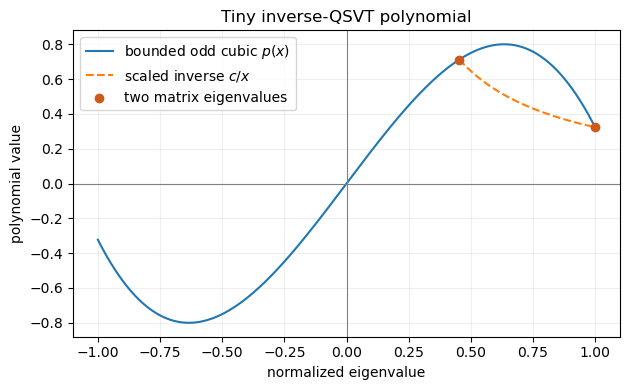

In [7]:
# 多项式与线路图。
grid = np.linspace(-1, 1, 2001)
poly_grid = coefficients[0] * grid + coefficients[1] * grid**3
fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(grid, poly_grid, label="bounded odd cubic $p(x)$")
positive = np.linspace(
    normalized_eigenvalues.min(),
    1.0,
    400,
)
ax.plot(
    positive,
    qsvt["polynomial_scale_c"] / positive,
    "--",
    label="scaled inverse $c/x$",
)
ax.scatter(
    normalized_eigenvalues,
    at_spectrum,
    color="#CD591A",
    zorder=5,
    label="two matrix eigenvalues",
)
ax.axhline(0, color="0.5", lw=0.8)
ax.axvline(0, color="0.5", lw=0.8)
ax.set(
    xlabel="normalized eigenvalue",
    ylabel="polynomial value",
    title="Tiny inverse-QSVT polynomial",
)
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "tiny-ridge-qsvt-polynomial.png",
    dpi=180,
)
plt.show()

logical_style = {"fold": 28, "idle_wires": False}
fig = ridge_logical.draw("mpl", style=logical_style)
fig.savefig(
    CIRCUIT_DIR / "tiny-ridge-qsvt-logical.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

fig = shadow_dense_compiled.draw(
    "mpl",
    fold=45,
    idle_wires=False,
)
fig.savefig(
    CIRCUIT_DIR / "tiny-ridge-shadow-dense-compiled.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## 5. Interferometric global-Clifford shadow

普通地测量 $|w\rangle$ 只能获得 $|\langle x|w\rangle|^2$，无法判断分类符号。
本实验准备

$$
|\widetilde w\rangle=
\frac{|0\rangle|0\rangle+|1\rangle|w\rangle}{\sqrt 2}.
$$

对每个测试态 $|x\rangle$ 定义

$$
|x_\pm\rangle=
\frac{|0\rangle|0\rangle\pm|1\rangle|x\rangle}{\sqrt 2},
\qquad
O_x=|x_+\rangle\langle x_+|-|x_-\rangle\langle x_-|.
$$

于是 $\langle O_x\rangle=\operatorname{Re}\langle x|w\rangle$。

每个 static QASM 使用一个随机 two-qubit global Clifford $C$. 对测量结果 $b$
的 shadow snapshot 为

$$
\hat\rho=(d+1)C^\dagger|b\rangle\langle b|C-I,\qquad d=4.
$$

Quafu 一条任务内不能逐 shot 更换 Clifford，因此这里提交
`N_SHADOW_SETTINGS` 条不同 Clifford，每条重复 `SHOTS` 次。这是
**batched global-Clifford shadow estimator**：distinct settings 数量和总
accepted shots 会分别报告，不能把重复 shots 都说成独立 random Cliffords。

为了在 $D=2$ 的 tiny 实验中做最强自检，本 notebook 会重建完整 $4\times4$
density estimator，再提取两个权重。这在当前规模合法，但不是论文
Lemma F.16 面向海量 observable 的可扩展实现。对 distinct Clifford settings
做的 cluster bootstrap 只给出固定测试集上的探索性区间，不是论文
i.i.d.-Clifford + median-of-means 定理的严格置信保证。


In [8]:
def measured_copy(circuit):
    measured = QuantumCircuit(4, 4)
    measured.compose(circuit, qubits=range(4), inplace=True)
    measured.measure(range(4), range(4))
    return measured


def calibration_circuit(qubit):
    circuit = QuantumCircuit(4, 4)
    circuit.x(qubit)
    circuit.measure(range(4), range(4))
    return circuit


def ridge_prepare_4q():
    circuit = QuantumCircuit(4)
    circuit.compose(
        ridge_dense_compiled,
        qubits=[0, 1, 2],
        inplace=True,
    )
    return measured_copy(circuit)


def ridge_verify_4q():
    circuit = QuantumCircuit(4)
    circuit.compose(
        ridge_dense_compiled,
        qubits=[0, 1, 2],
        inplace=True,
    )
    circuit.append(
        StatePreparation(target_weight).inverse(),
        [0],
    )
    return measured_copy(circuit)


def ridge_direct_control_4q():
    circuit = QuantumCircuit(4)
    circuit.append(StatePreparation(target_weight), [0])
    # Preserve the prepare/unprepare echo as a hardware control.
    circuit.barrier(0)
    circuit.append(StatePreparation(target_weight).inverse(), [0])
    return measured_copy(circuit)


def ideal_interferometric_preparation():
    circuit = QuantumCircuit(4)
    circuit.append(
        StatePreparation(target_interferometric_state),
        [0, 1],
    )
    return circuit


def shadow_circuit(preparation, clifford):
    circuit = QuantumCircuit(4)
    circuit.compose(preparation, qubits=range(4), inplace=True)
    circuit.compose(
        clifford.to_circuit(),
        qubits=[0, 1],
        inplace=True,
    )
    return measured_copy(circuit)


def complex_matrix_payload(matrix):
    return {
        "real": np.asarray(matrix).real.tolist(),
        "imag": np.asarray(matrix).imag.tolist(),
    }


def write_qasm_entry(
    circuit,
    experiment_id,
    family,
    stage,
    run_label,
    measurement_roles,
    extra=None,
):
    compiled = compile_u_cx(circuit)
    qasm_text = qasm2.dumps(compiled)
    parsed = qasm2.loads(qasm_text)
    assert parsed.num_qubits == parsed.num_clbits == 4
    assert int(parsed.count_ops().get("measure", 0)) == 4
    qasm_path = QASM_DIR / f"{experiment_id}.qasm"
    qasm_path.write_text(qasm_text, encoding="utf-8")
    entry = {
        "schema_version": 1,
        "experiment_id": experiment_id,
        "family": family,
        "stage": stage,
        "run_label": run_label,
        "qasm_path": str(qasm_path.relative_to(PROJECT_ROOT)),
        "qasm_sha256": sha256_text(qasm_text),
        "shots": int(SHOTS),
        "n_total_qubits": 4,
        "n_total_clbits": 4,
        "measurement_roles": measurement_roles,
        "logical_depth": int(circuit.depth()),
        "compiled_depth": int(compiled.depth()),
        "compiled_cx": int(compiled.count_ops().get("cx", 0)),
        "compiled_u": int(
            sum(
                compiled.count_ops().get(name, 0)
                for name in ["u", "u1", "u2", "u3"]
            )
        ),
        "backend_compilation_pending": True,
    }
    if extra:
        entry.update(extra)
    return entry


manifest_entries = []
manifest_entries.append(
    write_qasm_entry(
        calibration_circuit(0),
        "tiny_cal_4q_x_q0",
        "calibration",
        "calibration",
        "tiny_cal_4q_x_q0",
        {"q0": 0, "q1": 1, "q2": 2, "q3": 3},
        {"ideal_expected_bitstring": "0001"},
    )
)
manifest_entries.append(
    write_qasm_entry(
        calibration_circuit(1),
        "tiny_cal_4q_x_q1",
        "calibration",
        "calibration",
        "tiny_cal_4q_x_q1",
        {"q0": 0, "q1": 1, "q2": 2, "q3": 3},
        {"ideal_expected_bitstring": "0010"},
    )
)
manifest_entries.append(
    write_qasm_entry(
        calibration_circuit(2),
        "tiny_cal_4q_x_q2",
        "calibration",
        "calibration",
        "tiny_cal_4q_x_q2",
        {"q0": 0, "q1": 1, "q2": 2, "q3": 3},
        {"ideal_expected_bitstring": "0100"},
    )
)
manifest_entries.append(
    write_qasm_entry(
        calibration_circuit(3),
        "tiny_cal_4q_x_q3",
        "calibration",
        "calibration",
        "tiny_cal_4q_x_q3",
        {"q0": 0, "q1": 1, "q2": 2, "q3": 3},
        {"ideal_expected_bitstring": "1000"},
    )
)
manifest_entries.append(
    write_qasm_entry(
        ridge_direct_control_4q(),
        "tiny_ridge_direct_control",
        "ridge_control",
        "ridge",
        "tiny_ridge_direct_control",
        {"system": 0, "signal": 1, "real": 2, "idle": 3},
        {
            "ideal_expected_bitstring": "0000",
            "ideal_conditional_fidelity": 1.0,
        },
    )
)
manifest_entries.append(
    write_qasm_entry(
        ridge_prepare_4q(),
        "tiny_ridge_qsvt_prepare",
        "tiny_ridge_qsvt",
        "ridge",
        "tiny_ridge_qsvt_prepare",
        {"system": 0, "signal": 1, "real": 2, "idle": 3},
        {
            "ideal_success_probability": qsvt_success_probability,
            "ideal_conditional_fidelity": None,
        },
    )
)
manifest_entries.append(
    write_qasm_entry(
        ridge_verify_4q(),
        "tiny_ridge_qsvt_verify",
        "tiny_ridge_qsvt",
        "ridge",
        "tiny_ridge_qsvt_verify",
        {"system": 0, "signal": 1, "real": 2, "idle": 3},
        {
            "ideal_success_probability": qsvt_success_probability,
            "ideal_conditional_fidelity": qsvt_conditional_fidelity,
        },
    )
)

shadow_settings = []
ideal_shadow_preparation = ideal_interferometric_preparation()
for setting in range(int(N_SHADOW_SETTINGS)):
    seed = int(SHADOW_SEED + setting)
    clifford = random_clifford(2, seed=seed)
    clifford_payload = {
        "shadow_setting": setting,
        "clifford_seed": seed,
        "clifford_symplectic_matrix": (
            clifford.symplectic_matrix.astype(int).tolist()
        ),
        "clifford_phase": clifford.phase.astype(int).tolist(),
        "clifford_matrix": complex_matrix_payload(
            clifford.to_matrix()
        ),
        "shadow_ensemble": "global_clifford",
        "shadow_sampling": "batched_static_setting",
        "ideal_success_probability": 1.0,
    }
    shadow_settings.append(
        {
            "setting": setting,
            "seed": seed,
            "clifford": clifford,
        }
    )
    manifest_entries.append(
        write_qasm_entry(
            shadow_circuit(
                ideal_shadow_preparation,
                clifford,
            ),
            f"tiny_shadow_control_s{setting:02d}",
            "interferometric_shadow_control",
            "shadow_control",
            f"tiny_shadow_control_s{setting:02d}",
            {
                "reference": 0,
                "system": 1,
                "signal": 2,
                "real": 3,
            },
            clifford_payload,
        )
    )
    full_payload = dict(clifford_payload)
    full_payload["ideal_success_probability"] = (
        shadow_herald_probability
    )
    full_payload["dense_resynthesis_boundary"] = (
        "Exact tiny-unitary equivalence; exponentially costly to "
        "construct and not scalable."
    )
    manifest_entries.append(
        write_qasm_entry(
            shadow_circuit(
                shadow_dense_compiled,
                clifford,
            ),
            f"tiny_shadow_qsvt_s{setting:02d}",
            "interferometric_shadow_qsvt",
            "shadow_qsvt",
            f"tiny_shadow_qsvt_s{setting:02d}",
            {
                "reference": 0,
                "system": 1,
                "signal": 2,
                "real": 3,
            },
            full_payload,
        )
    )

manifest_payload = {
    "schema_version": 1,
    "experiment": "tiny IMDb Ridge inverse QSVT + shadows",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "entries": manifest_entries,
    "model_path": str(MODEL_PATH.relative_to(PROJECT_ROOT)),
    "data_summary_path": str(
        DATA_SUMMARY_PATH.relative_to(PROJECT_ROOT)
    ),
    "environment": ENVIRONMENT,
}
write_json_atomic(MANIFEST_PATH, manifest_payload)
pd.DataFrame(
    [
        {
            key: value
            for key, value in entry.items()
            if key
            not in {
                "measurement_roles",
                "clifford_matrix",
                "clifford_symplectic_matrix",
                "clifford_phase",
            }
        }
        for entry in manifest_entries
    ]
).to_csv(MANIFEST_CSV_PATH, index=False)

entry_by_id = {
    entry["experiment_id"]: entry for entry in manifest_entries
}
plan_by_stage = {}
for entry in manifest_entries:
    plan_by_stage.setdefault(entry["stage"], []).append(entry)

print(
    "Generated QASM:",
    len(manifest_entries),
    "entries; stage counts:",
    {key: len(value) for key, value in plan_by_stage.items()},
)
pd.DataFrame(manifest_entries)[
    [
        "experiment_id",
        "stage",
        "compiled_depth",
        "compiled_cx",
        "shots",
    ]
]


Generated QASM: 31 entries; stage counts: {'calibration': 4, 'ridge': 3, 'shadow_control': 12, 'shadow_qsvt': 12}


,experiment_id,stage,compiled_depth,compiled_cx,shots
0,tiny_cal_4q_x_q0,calibration,2,0,2048
1,tiny_cal_4q_x_q1,calibration,2,0,2048
2,tiny_cal_4q_x_q2,calibration,2,0,2048
3,tiny_cal_4q_x_q3,calibration,2,0,2048
4,tiny_ridge_direct_control,ridge,3,0,2048
5,tiny_ridge_qsvt_prepare,ridge,32,18,2048
6,tiny_ridge_qsvt_verify,ridge,32,18,2048
7,tiny_shadow_control_s00,shadow_control,8,3,2048
8,tiny_shadow_qsvt_s00,shadow_qsvt,184,96,2048
9,tiny_shadow_control_s01,shadow_control,6,2,2048


## 6. Offline QASM audit and local ideal shadow

离线审计会重新读取每条磁盘 QASM、核对 hash、4q/4c/4measure schema 和基础门集。
随后 Aer 运行相同 QASM，验证：

- bit-order parser；
- Ridge heralding 与 conditional fidelity；
- global-Clifford inverse channel；
- 一份 shadow 数据能离线预测全部 25,000 条 test reviews。


In [9]:
def normalize_counts(counts, order=BITSTRING_ORDER):
    if not isinstance(counts, dict) or not counts:
        raise ValueError("Counts must be a nonempty mapping.")
    normalized = {}
    for raw_key, raw_value in counts.items():
        bits = re.sub(r"[^01]", "", str(raw_key))
        if len(bits) != 4:
            raise ValueError(f"Expected 4-bit count key, got {raw_key!r}")
        value = float(raw_value)
        if not np.isfinite(value) or value < 0:
            raise ValueError(
                f"Counts must be finite and nonnegative: {raw_value!r}"
            )
        if order == "reversed":
            bits = bits[::-1]
        normalized[bits] = normalized.get(bits, 0.0) + value
    if not np.isfinite(sum(normalized.values())) or sum(
        normalized.values()
    ) <= 0:
        raise ValueError("Counts total must be finite and positive.")
    return normalized


def bit_for_clbit(bits, clbit_index):
    return bits[-1 - int(clbit_index)]


def probability_from_counts(counts, predicate):
    total = float(sum(counts.values()))
    if total <= 0:
        return np.nan
    return float(
        sum(value for bits, value in counts.items() if predicate(bits))
        / total
    )


def wilson_interval(successes, trials, z=1.959963984540054):
    successes = float(successes)
    trials = float(trials)
    if trials <= 0:
        return [np.nan, np.nan]
    probability = successes / trials
    denominator = 1.0 + z**2 / trials
    center = (
        probability + z**2 / (2.0 * trials)
    ) / denominator
    half_width = (
        z
        * np.sqrt(
            probability * (1.0 - probability) / trials
            + z**2 / (4.0 * trials**2)
        )
        / denominator
    )
    return [
        float(max(0.0, center - half_width)),
        float(min(1.0, center + half_width)),
    ]


def parse_basic_metrics(counts, entry):
    roles = entry["measurement_roles"]
    family = entry["family"]
    total = float(sum(counts.values()))
    row = {
        "shots_observed": total,
        "dominant_bitstring": max(counts, key=counts.get),
    }
    if family == "calibration":
        expected = entry["ideal_expected_bitstring"]
        row["calibration_expected_bitstring"] = expected
        row["calibration_dominant_matches_expected"] = (
            row["dominant_bitstring"] == expected
        )
        row["calibration_expected_probability"] = (
            counts.get(expected, 0.0) / total
        )
        row["calibration_expected_probability_wilson95"] = (
            wilson_interval(counts.get(expected, 0.0), total)
        )
    elif family in {"ridge_control", "tiny_ridge_qsvt"}:
        herald_count = sum(
            value
            for bits, value in counts.items()
            if (
                bit_for_clbit(bits, roles["signal"]) == "0"
                and bit_for_clbit(bits, roles["real"]) == "0"
            )
        )
        verifier_count = sum(
            value
            for bits, value in counts.items()
            if (
                bit_for_clbit(bits, roles["signal"]) == "0"
                and bit_for_clbit(bits, roles["real"]) == "0"
                and bit_for_clbit(bits, roles["system"]) == "0"
            )
        )
        row["herald_success_events"] = float(herald_count)
        row["herald_success_probability"] = float(
            herald_count / total
        )
        row["herald_success_probability_wilson95"] = (
            wilson_interval(herald_count, total)
        )
        conditional_system_zero_probability = (
            float(verifier_count / herald_count)
            if herald_count > 0
            else np.nan
        )
        conditional_system_zero_wilson95 = wilson_interval(
            verifier_count,
            herald_count,
        )
        if (
            family == "ridge_control"
            or entry["experiment_id"].endswith("_verify")
        ):
            row["conditional_fidelity"] = (
                conditional_system_zero_probability
            )
            row["conditional_fidelity_wilson95"] = (
                conditional_system_zero_wilson95
            )
        else:
            # The prepare circuit has no inverse-state verifier.  Its
            # conditional system-zero rate is a population, not fidelity.
            row["conditional_system_zero_probability"] = (
                conditional_system_zero_probability
            )
            row["conditional_system_zero_probability_wilson95"] = (
                conditional_system_zero_wilson95
            )
        row["idle_zero_probability"] = probability_from_counts(
            counts,
            lambda bits: bit_for_clbit(bits, roles["idle"]) == "0",
        )
    elif family.startswith("interferometric_shadow"):
        accepted = sum(
            value
            for bits, value in counts.items()
            if (
                bit_for_clbit(bits, roles["signal"]) == "0"
                and bit_for_clbit(bits, roles["real"]) == "0"
            )
        )
        row["herald_success_events"] = float(accepted)
        row["herald_success_probability"] = float(accepted / total)
        row["herald_success_probability_wilson95"] = (
            wilson_interval(accepted, total)
        )
    return row


def clifford_matrix_from_entry(entry):
    payload = entry["clifford_matrix"]
    return np.asarray(payload["real"]) + 1j * np.asarray(payload["imag"])


def shadow_setting_density(counts, entry):
    roles = entry["measurement_roles"]
    clifford = clifford_matrix_from_entry(entry)
    accepted = 0.0
    density = np.zeros((4, 4), dtype=complex)
    for bits, count in counts.items():
        if (
            bit_for_clbit(bits, roles["signal"]) != "0"
            or bit_for_clbit(bits, roles["real"]) != "0"
        ):
            continue
        system_bit = bit_for_clbit(bits, roles["system"])
        reference_bit = bit_for_clbit(bits, roles["reference"])
        outcome = int(system_bit + reference_bit, 2)
        basis_state = np.zeros(4, dtype=complex)
        basis_state[outcome] = 1.0
        stabilizer = clifford.conj().T @ basis_state
        snapshot = (
            5.0 * np.outer(stabilizer, stabilizer.conj())
            - np.eye(4)
        )
        density += float(count) * snapshot
        accepted += float(count)
    if accepted <= 0:
        raise ValueError(
            f"No herald-success events for {entry['experiment_id']}"
        )
    return density / accepted, accepted


def shadow_weight_from_density(density):
    # basis ordering is |system reference>.
    return np.asarray(
        [
            2 * density[1, 0].real,
            2 * density[3, 0].real,
        ]
    )


def normalize_test_vectors(vectors):
    norms = np.linalg.norm(vectors, axis=1)
    normalized = np.zeros_like(vectors, dtype=float)
    nonzero = norms > 0
    normalized[nonzero] = vectors[nonzero] / norms[nonzero, None]
    return normalized, nonzero


normalized_test, nonzero_test = normalize_test_vectors(z_test)


def evaluate_shadow_collection(counts_by_experiment, family, seed=0):
    selected_entries = [
        entry
        for entry in manifest_entries
        if entry["family"] == family
        and entry["experiment_id"] in counts_by_experiment
    ]
    selected_entries = sorted(
        selected_entries,
        key=lambda item: item["shadow_setting"],
    )
    if len(selected_entries) < 2:
        raise ValueError(f"Need at least 2 settings for {family}.")
    setting_densities, accepted_events = [], []
    for entry in selected_entries:
        density, accepted = shadow_setting_density(
            counts_by_experiment[entry["experiment_id"]],
            entry,
        )
        setting_densities.append(density)
        accepted_events.append(accepted)
    setting_densities = np.asarray(setting_densities)
    density_mean = setting_densities.mean(axis=0)
    weight_estimate = shadow_weight_from_density(density_mean)
    predictions = np.where(
        normalized_test @ weight_estimate >= 0,
        1,
        -1,
    )
    accuracy = float(accuracy_score(y_test, predictions))
    weight_norm = float(np.linalg.norm(weight_estimate))
    if weight_norm <= 0:
        raise ValueError("Shadow weight estimate has zero norm.")
    signed_direction_cosine = float(
        np.dot(weight_estimate / weight_norm, target_weight)
    )
    direction_overlap_squared = float(
        signed_direction_cosine**2
    )
    target_overlaps = normalized_test @ target_weight
    estimated_overlaps = normalized_test @ weight_estimate
    overlap_errors = (
        estimated_overlaps[nonzero_test]
        - target_overlaps[nonzero_test]
    )
    interferometric_target_overlap_estimate = float(
        np.vdot(
            target_interferometric_state,
            density_mean @ target_interferometric_state,
        ).real
    )

    rng = np.random.default_rng(seed)
    bootstrap_accuracy = []
    bootstrap_signed_cosine = []
    for _ in range(int(BOOTSTRAP_REPEATS)):
        indices = rng.integers(
            0,
            len(setting_densities),
            size=len(setting_densities),
        )
        bootstrap_density = setting_densities[indices].mean(axis=0)
        bootstrap_weight = shadow_weight_from_density(
            bootstrap_density
        )
        if np.linalg.norm(bootstrap_weight) == 0:
            continue
        bootstrap_predictions = np.where(
            normalized_test @ bootstrap_weight >= 0,
            1,
            -1,
        )
        bootstrap_accuracy.append(
            accuracy_score(y_test, bootstrap_predictions)
        )
        bootstrap_signed_cosine.append(
            np.dot(
                bootstrap_weight
                / np.linalg.norm(bootstrap_weight),
                target_weight,
            )
        )
    complete_setting_set = (
        len(selected_entries) == int(N_SHADOW_SETTINGS)
    )
    accuracy_interval = (
        np.percentile(bootstrap_accuracy, [2.5, 97.5])
        if complete_setting_set
        else None
    )
    cosine_interval = (
        np.percentile(bootstrap_signed_cosine, [2.5, 97.5])
        if complete_setting_set
        else None
    )
    return {
        "family": family,
        "distinct_clifford_settings": len(selected_entries),
        "configured_clifford_settings": int(N_SHADOW_SETTINGS),
        "complete_setting_set": complete_setting_set,
        "accepted_events_total": float(sum(accepted_events)),
        "accepted_events_by_setting": accepted_events,
        "shadow_weight": weight_estimate,
        "shadow_weight_norm": weight_norm,
        "shadow_weight_norm_ratio_to_target": weight_norm,
        "signed_direction_cosine": signed_direction_cosine,
        "direction_overlap_squared_sign_insensitive": (
            direction_overlap_squared
        ),
        "interferometric_target_overlap_estimate": (
            interferometric_target_overlap_estimate
        ),
        "signed_overlap_mae": float(
            np.mean(np.abs(overlap_errors))
        ),
        "signed_overlap_rmse": float(
            np.sqrt(np.mean(overlap_errors**2))
        ),
        "signed_overlap_max_abs_error": float(
            np.max(np.abs(overlap_errors))
        ),
        "test_accuracy": accuracy,
        "test_accuracy_setting_bootstrap_interval95": (
            accuracy_interval
        ),
        "signed_direction_cosine_setting_bootstrap_interval95": (
            cosine_interval
        ),
        "bootstrap_unit": "distinct Clifford setting",
        "bootstrap_interpretation": (
            "Exploratory cluster bootstrap conditional on the fixed "
            "test set; not the paper's iid-Clifford median-of-means "
            "confidence guarantee."
        ),
    }


audit_rows = []
for entry in manifest_entries:
    path = PROJECT_ROOT / entry["qasm_path"]
    text = path.read_text(encoding="utf-8")
    circuit = qasm2.loads(text)
    observed_hash = sha256_text(text)
    row = {
        "experiment_id": entry["experiment_id"],
        "hash_matches": observed_hash == entry["qasm_sha256"],
        "qubits": circuit.num_qubits,
        "clbits": circuit.num_clbits,
        "measurements": int(circuit.count_ops().get("measure", 0)),
        "schema_pass": (
            circuit.num_qubits == 4
            and circuit.num_clbits == 4
            and int(circuit.count_ops().get("measure", 0)) == 4
        ),
        "basis_pass": set(circuit.count_ops()).issubset(
            {"u1", "u2", "u3", "cx", "measure", "barrier"}
        ),
    }
    row["audit_pass"] = all(
        [
            row["hash_matches"],
            row["schema_pass"],
            row["basis_pass"],
        ]
    )
    audit_rows.append(row)

audit_table = pd.DataFrame(audit_rows)
assert audit_table["audit_pass"].all()
audit_table.to_csv(RESULT_DIR / "offline_qasm_audit.csv", index=False)

local_counts = {}
local_basic_rows = []
local_shadow_summaries = []
if RUN_LOCAL_IDEAL_SHOTS:
    simulator = AerSimulator()
    for index, entry in enumerate(manifest_entries):
        text = (PROJECT_ROOT / entry["qasm_path"]).read_text(
            encoding="utf-8"
        )
        circuit = qasm2.loads(text)
        result = simulator.run(
            circuit,
            shots=int(SHOTS),
            seed_simulator=int(LOCAL_SIMULATOR_SEED + index),
        ).result()
        counts = normalize_counts(
            result.get_counts(),
            order="qiskit",
        )
        local_counts[entry["experiment_id"]] = counts
        local_basic_rows.append(
            {
                "experiment_id": entry["experiment_id"],
                "family": entry["family"],
                **parse_basic_metrics(counts, entry),
            }
        )
    write_json_atomic(LOCAL_COUNTS_PATH, local_counts)
    for family in [
        "interferometric_shadow_control",
        "interferometric_shadow_qsvt",
    ]:
        local_shadow_summaries.append(
            evaluate_shadow_collection(
                local_counts,
                family,
                seed=LOCAL_SIMULATOR_SEED,
            )
        )
    write_json_atomic(
        LOCAL_SUMMARY_PATH,
        {
            "classical_tiny_ridge_test_accuracy": classical_test_accuracy,
            "polarity_rule_test_accuracy":
                polarity_baseline_test_accuracy,
            "qsvt_success_probability_statevector":
                qsvt_success_probability,
            "qsvt_conditional_fidelity_statevector":
                qsvt_conditional_fidelity,
            "shadow_herald_probability_statevector":
                shadow_herald_probability,
            "interferometric_fidelity_statevector":
                interferometric_fidelity,
            "shadow_summaries": local_shadow_summaries,
            "basic_metrics": local_basic_rows,
        },
    )

print(
    f"Offline QASM audit PASS: {len(audit_table)} circuits; "
    f"failures: {(~audit_table['audit_pass']).sum()}"
)
if local_shadow_summaries:
    display(
        pd.DataFrame(local_shadow_summaries)[
            [
                "family",
                "distinct_clifford_settings",
                "accepted_events_total",
                "shadow_weight_norm_ratio_to_target",
                "signed_direction_cosine",
                "signed_overlap_rmse",
                "test_accuracy",
                "test_accuracy_setting_bootstrap_interval95",
            ]
        ]
    )


Offline QASM audit PASS: 31 circuits; failures: 0


,family,distinct_clifford_settings,accepted_events_total,shadow_weight_norm_ratio_to_target,signed_direction_cosine,signed_overlap_rmse,test_accuracy,test_accuracy_setting_bootstrap_interval95
0,interferometric_shadow_control,12,24576.0,0.619935,0.999931,0.304825,0.84872,"[0.77008, 0.84892]"
1,interferometric_shadow_qsvt,12,4625.0,0.623143,0.999431,0.302559,0.84900,"[0.77008, 0.849]"


## 7. Quafu-SQC status / submit / fetch

建议阶段顺序：

1. `calibration`：`q0`、`q1`、`q2`、`q3` 四条 one-hot；
2. `ridge`：direct control、QSVT prepare、QSVT verify；
3. `shadow_control`：浅层、直接准备 $|\widetilde w\rangle$，验证 shadow
   readout；
4. `shadow_qsvt`：4-qubit 完整 QSVT-output interferometric shadow。

真正提交还需要：

```python
ACTION = "submit"
CONFIRM_REAL_SUBMISSION = "RUN_TINY_RIDGE_QSVT"
```

`RUN_STAGE` 选择阶段，`BATCH_START` 和 `BATCH_SIZE` 控制当前小批次。
shadow 每个 setting 是一条真机任务；完成一批后把 `BATCH_START` 增加
`BATCH_SIZE`。registry 会阻止同一 label 重复提交。

`shadow_qsvt` 还必须显式设置：

```python
ALLOW_FULL_QSVT_SHADOW_SUBMISSION = True
```

并填写同一组连通的四个 `TARGET_QUBITS`。提交 full-QSVT 之前，还要把选定的
4 条 calibration、1 条 Ridge verifier、12 条 `shadow_control` 的 task id
冻结到 `HARDWARE_COHORT_TASK_IDS`，在平台核对它们属于可比较的设备时间窗后设置：

```python
CONFIRM_COHERENT_HARDWARE_COHORT = "I_REVIEWED_TASK_TIME_WINDOW"
```

代码会要求每个 prerequisite experiment **恰好一条**可信结果，并检查同 backend、
compiler、physical layout，以及 calibration、Ridge herald/verifier 和 shallow-shadow
的 Wilson 下界、setting-bootstrap 下界与 signed-overlap RMSE。默认阈值是保守的
工程发布门槛，不是论文复杂度定理；不通过时 full 提交会被阻止。

full-QSVT 的 12 条结果取回后，把它们的 task id 也加入同一个列表（最终共 29 条）。
只有完整、无重复、固定 layout 且前置质量门槛通过时，图中真机点才标为 `final`；
否则最多标为 `provisional`。仅打开布尔开关不能绕过这些证据。

取回时设置 `ACTION="fetch"` 和 `FETCH_RUN_LABELS=["*"]`。未完成任务只记录状态，
不会调用 result endpoint，也不会重新提交。


In [10]:
FINISHED_STATES = {"finished", "completed", "success"}
FAILED_STATES = {"failed", "error", "cancelled", "canceled", "deleted"}
NETWORK_ACTIONS = {"status", "submit", "fetch"}


def normalized_status(value):
    return str(value).strip().lower()


def backend_value_is_available(value):
    queue_value = (
        isinstance(value, (int, np.integer))
        and not isinstance(value, (bool, np.bool_))
        and int(value) >= 0
    )
    online_label = (
        isinstance(value, str)
        and value.strip().lower() in {"online", "available", "idle"}
    )
    return queue_value or online_label


def valid_task_id(value):
    return (
        isinstance(value, (int, np.integer))
        and not isinstance(value, (bool, np.bool_))
        and int(value) > 0
    )


task_manager = None
live_backend_status = None
if ACTION in NETWORK_ACTIONS:
    from quafu import Task

    token = os.environ.get("QPU_API_TOKEN") or getpass(
        "请输入 Quafu-SQC token（输入不会显示）: "
    )
    task_manager = Task(token)
    if ACTION in {"status", "submit"}:
        live_backend_status = task_manager.status()
        if not isinstance(live_backend_status, dict):
            raise RuntimeError(
                "Fail-closed: backend status is not a mapping."
            )
        backend_value = live_backend_status.get(BACKEND)
        if not backend_value_is_available(backend_value):
            raise RuntimeError(
                f"Fail-closed: unexpected {BACKEND} state "
                f"{backend_value!r}."
            )
        RAW_DIR.mkdir(parents=True, exist_ok=True)
        write_json_atomic(
            RAW_DIR
            / (
                "backend_status_"
                + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
                + ".json"
            ),
            live_backend_status,
        )
        print("Live backend status:", live_backend_status)
elif ACTION == "dry_run":
    print("Dry run: no token read, no network request.")

if ACTION == "status":
    print(f"{BACKEND} queue value:", live_backend_status.get(BACKEND))


Dry run: no token read, no network request.


In [11]:
def read_registry():
    if not REGISTRY_PATH.exists():
        return []
    payload = json.loads(REGISTRY_PATH.read_text(encoding="utf-8"))
    if not isinstance(payload, list):
        raise ValueError("task_registry.json must contain a list.")
    return payload


def submission_fingerprint(record):
    return json.dumps(
        {
            key: record[key]
            for key in [
                "run_label",
                "experiment_id",
                "qasm_sha256",
                "backend",
                "compiler",
                "correct",
                "open_dd",
                "target_qubits",
            ]
        },
        sort_keys=True,
    )


def revalidate_qasm(entry):
    path = PROJECT_ROOT / entry["qasm_path"]
    text = path.read_text(encoding="utf-8")
    if sha256_text(text) != entry["qasm_sha256"]:
        raise RuntimeError(
            f"QASM hash mismatch: {entry['experiment_id']}"
        )
    circuit = qasm2.loads(text)
    if (
        circuit.num_qubits != 4
        or circuit.num_clbits != 4
        or int(circuit.count_ops().get("measure", 0)) != 4
    ):
        raise RuntimeError(
            f"QASM schema mismatch: {entry['experiment_id']}"
        )
    allowed_basis = {"u1", "u2", "u3", "cx", "measure", "barrier"}
    if not set(circuit.count_ops()).issubset(allowed_basis):
        raise RuntimeError(
            f"QASM basis mismatch: {entry['experiment_id']}"
        )
    return path, text


def trusted_prerequisite_rows():
    if not HARDWARE_JSON_PATH.exists():
        return []
    payload = json.loads(
        HARDWARE_JSON_PATH.read_text(encoding="utf-8")
    )
    if not isinstance(payload, list):
        raise ValueError("hardware_results.json must contain a list.")
    requested_task_ids = {
        int(item) for item in HARDWARE_COHORT_TASK_IDS
    }
    return [
        row
        for row in payload
        if (
            row.get("fetch_reason") == "ok"
            and row.get("task_id_matches") is True
            and row.get("qasm_provenance_pass") is True
            and (
                not requested_task_ids
                or int(row.get("task_id", -1))
                in requested_task_ids
            )
        )
    ]


def finite_interval_lower(row, key):
    interval = row.get(key)
    if not isinstance(interval, (list, tuple)) or len(interval) != 2:
        return np.nan
    try:
        value = float(interval[0])
    except (TypeError, ValueError):
        return np.nan
    return value if np.isfinite(value) else np.nan


def finite_min(values):
    finite = [float(value) for value in values if np.isfinite(value)]
    return min(finite) if finite else np.nan


def prerequisite_quality_report(rows, signature):
    coherent = [
        row
        for row in rows
        if all(
            row.get(key) == value
            for key, value in signature.items()
        )
    ]
    calibration_ids = {
        f"tiny_cal_4q_x_q{qubit}" for qubit in range(4)
    }
    calibration_rows = [
        row
        for row in coherent
        if row.get("experiment_id") in calibration_ids
    ]
    calibration_row_ids = [
        row.get("experiment_id") for row in calibration_rows
    ]
    calibration_lower_min = finite_min(
        finite_interval_lower(
            row,
            "calibration_expected_probability_wilson95",
        )
        for row in calibration_rows
    )

    ridge_rows = [
        row
        for row in coherent
        if row.get("experiment_id") == "tiny_ridge_qsvt_verify"
    ]
    ridge_herald_lower = finite_min(
        finite_interval_lower(
            row,
            "herald_success_probability_wilson95",
        )
        for row in ridge_rows
    )
    ridge_fidelity_lower = finite_min(
        finite_interval_lower(
            row,
            "conditional_fidelity_wilson95",
        )
        for row in ridge_rows
    )

    required_control_ids = {
        entry["experiment_id"]
        for entry in manifest_entries
        if entry["family"] == "interferometric_shadow_control"
    }
    control_rows = [
        row
        for row in coherent
        if row.get("family") == "interferometric_shadow_control"
    ]
    control_row_ids = [
        row.get("experiment_id") for row in control_rows
    ]
    control_exact = bool(
        len(control_row_ids) == len(required_control_ids)
        and set(control_row_ids) == required_control_ids
    )
    control_herald_lower = finite_min(
        finite_interval_lower(
            row,
            "herald_success_probability_wilson95",
        )
        for row in control_rows
    )
    control_summary = None
    control_error = ""
    if control_exact:
        try:
            control_summary = evaluate_shadow_collection(
                {
                    row["experiment_id"]: row["counts_qiskit"]
                    for row in control_rows
                },
                "interferometric_shadow_control",
                seed=SHADOW_SEED + 313,
            )
        except Exception as exc:
            control_error = f"{type(exc).__name__}: {exc}"

    control_cosine_lower = np.nan
    control_accuracy_lower = np.nan
    control_overlap_rmse = np.nan
    if control_summary is not None:
        cosine_interval = control_summary.get(
            "signed_direction_cosine_setting_bootstrap_interval95"
        )
        accuracy_interval = control_summary.get(
            "test_accuracy_setting_bootstrap_interval95"
        )
        if cosine_interval is not None and len(cosine_interval) == 2:
            control_cosine_lower = float(cosine_interval[0])
        if accuracy_interval is not None and len(accuracy_interval) == 2:
            control_accuracy_lower = float(accuracy_interval[0])
        control_overlap_rmse = float(
            control_summary["signed_overlap_rmse"]
        )

    calibration_exact = bool(
        len(calibration_row_ids) == len(calibration_ids)
        and set(calibration_row_ids) == calibration_ids
    )
    checks = {
        "explicit_task_cohort": bool(HARDWARE_COHORT_TASK_IDS),
        "manual_time_window_confirmation": (
            CONFIRM_COHERENT_HARDWARE_COHORT
            == "I_REVIEWED_TASK_TIME_WINDOW"
        ),
        "calibration_exactly_one_each": calibration_exact,
        "calibration_dominant_matches_expected": bool(
            calibration_exact
            and all(
                row.get("calibration_dominant_matches_expected") is True
                for row in calibration_rows
            )
        ),
        "calibration_wilson_lower": bool(
            np.isfinite(calibration_lower_min)
            and calibration_lower_min
            >= MIN_CALIBRATION_EXPECTED_WILSON_LOWER
        ),
        "ridge_verifier_exactly_one": len(ridge_rows) == 1,
        "ridge_herald_wilson_lower": bool(
            np.isfinite(ridge_herald_lower)
            and ridge_herald_lower >= MIN_RIDGE_HERALD_WILSON_LOWER
        ),
        "ridge_fidelity_wilson_lower": bool(
            np.isfinite(ridge_fidelity_lower)
            and ridge_fidelity_lower
            > MIN_RIDGE_VERIFIER_WILSON_LOWER
        ),
        "control_exactly_one_per_setting": control_exact,
        "control_herald_wilson_lower": bool(
            np.isfinite(control_herald_lower)
            and control_herald_lower
            >= MIN_SHADOW_CONTROL_HERALD_WILSON_LOWER
        ),
        "control_cosine_bootstrap_lower": bool(
            np.isfinite(control_cosine_lower)
            and control_cosine_lower
            >= MIN_SHADOW_CONTROL_COSINE_BOOTSTRAP_LOWER
        ),
        "control_overlap_rmse": bool(
            np.isfinite(control_overlap_rmse)
            and control_overlap_rmse
            <= MAX_SHADOW_CONTROL_SIGNED_OVERLAP_RMSE
        ),
        "control_accuracy_bootstrap_lower": bool(
            np.isfinite(control_accuracy_lower)
            and control_accuracy_lower
            >= MIN_SHADOW_CONTROL_ACCURACY_BOOTSTRAP_LOWER
        ),
    }
    return {
        "signature": signature,
        "coherent_trusted_task_ids": sorted(
            int(row["task_id"])
            for row in coherent
            if valid_task_id(row.get("task_id"))
        ),
        "calibration_wilson_lower_min": calibration_lower_min,
        "ridge_herald_wilson_lower": ridge_herald_lower,
        "ridge_fidelity_wilson_lower": ridge_fidelity_lower,
        "control_herald_wilson_lower_min": control_herald_lower,
        "control_cosine_bootstrap_lower": control_cosine_lower,
        "control_signed_overlap_rmse": control_overlap_rmse,
        "control_accuracy_bootstrap_lower": control_accuracy_lower,
        "control_evaluation_error": control_error,
        "checks": checks,
        "quality_pass": bool(all(checks.values())),
        "interpretation": (
            "Conservative engineering release gate. The setting-level "
            "bootstrap is exploratory and is not the paper's iid-"
            "Clifford median-of-means theorem."
        ),
    }


def validate_full_shadow_prerequisites():
    if not HARDWARE_COHORT_TASK_IDS:
        raise RuntimeError(
            "Full shadow blocked: explicitly list the 4 calibration, "
            "1 Ridge verifier, and 12 shadow_control task ids in "
            "HARDWARE_COHORT_TASK_IDS."
        )
    if (
        CONFIRM_COHERENT_HARDWARE_COHORT
        != "I_REVIEWED_TASK_TIME_WINDOW"
    ):
        raise RuntimeError(
            "Full shadow blocked: review platform timestamps and set "
            "CONFIRM_COHERENT_HARDWARE_COHORT exactly to "
            "'I_REVIEWED_TASK_TIME_WINDOW'."
        )
    rows = trusted_prerequisite_rows()
    current_signature = {
        "backend": BACKEND,
        "compiler": DEFAULT_COMPILER,
        "target_qubits": [int(item) for item in TARGET_QUBITS],
    }
    report = prerequisite_quality_report(rows, current_signature)
    if not report["quality_pass"]:
        failed = [
            name
            for name, passed in report["checks"].items()
            if not passed
        ]
        raise RuntimeError(
            "Full shadow blocked by prerequisite quality gate: "
            + ", ".join(failed)
            + "\n"
            + json.dumps(
                report,
                ensure_ascii=False,
                indent=2,
                default=str,
            )
        )
    return report


if ACTION == "status":
    registry_status_rows = []
    for record in read_registry():
        task_id = record.get("task_id")
        if not valid_task_id(task_id):
            continue
        try:
            task_status = task_manager.status(int(task_id))
            status_error = ""
        except Exception as exc:
            task_status = None
            status_error = f"{type(exc).__name__}: {exc}"
        registry_status_rows.append(
            {
                "checked_at_utc": datetime.now(
                    timezone.utc
                ).isoformat(),
                "run_label": record.get("run_label"),
                "experiment_id": record.get("experiment_id"),
                "task_id": int(task_id),
                "status": task_status,
                "error": status_error,
            }
        )
    if registry_status_rows:
        RAW_DIR.mkdir(parents=True, exist_ok=True)
        status_snapshot_path = (
            RAW_DIR
            / (
                "task_status_"
                + datetime.now(timezone.utc).strftime(
                    "%Y%m%dT%H%M%SZ"
                )
                + ".json"
            )
        )
        write_json_atomic(status_snapshot_path, registry_status_rows)
        display(pd.DataFrame(registry_status_rows))
    else:
        print("Registry contains no submitted task ids.")


selected_stage_entries = sorted(
    plan_by_stage[RUN_STAGE],
    key=lambda item: item["experiment_id"],
)
selected_batch = selected_stage_entries[
    int(BATCH_START) : int(BATCH_START) + int(BATCH_SIZE)
]

submitted_records = []
if ACTION == "submit":
    if CONFIRM_REAL_SUBMISSION != "RUN_TINY_RIDGE_QSVT":
        raise ValueError(
            "Set CONFIRM_REAL_SUBMISSION exactly to "
            "'RUN_TINY_RIDGE_QSVT'."
        )
    if not selected_batch:
        raise ValueError("Selected stage/batch contains no tasks.")
    if len(selected_batch) > int(MAX_TASKS_PER_SUBMISSION_CELL):
        raise ValueError("Submission batch exceeds the configured cap.")
    if (
        RUN_STAGE == "shadow_qsvt"
        and not ALLOW_FULL_QSVT_SHADOW_SUBMISSION
    ):
        raise RuntimeError(
            "Full QSVT shadow is blocked. Pass calibration, ridge, "
            "and shadow_control first, then explicitly allow it."
        )
    if DEFAULT_COMPILER not in ALLOWED_COMPILERS:
        raise ValueError("Unsupported compiler.")
    if USE_READOUT_CORRECTION:
        raise NotImplementedError(
            "Readout-corrected quasi-count analysis is intentionally "
            "disabled here. Keep USE_READOUT_CORRECTION=False so raw "
            "counts and Wilson intervals remain well-defined."
        )
    if TARGET_QUBITS:
        if len(TARGET_QUBITS) != 4:
            raise ValueError("TARGET_QUBITS must have exactly 4 entries.")
        if (
            len(set(TARGET_QUBITS)) != 4
            or any(int(item) < 0 for item in TARGET_QUBITS)
        ):
            raise ValueError(
                "TARGET_QUBITS must be unique nonnegative integers."
            )
    if (
        RUN_STAGE == "shadow_qsvt"
        and REQUIRE_FIXED_LAYOUT_FOR_FULL_SHADOW
        and not TARGET_QUBITS
    ):
        raise RuntimeError(
            "Full QSVT shadow requires a fixed connected 4-qubit "
            "TARGET_QUBITS layout."
        )
    if RUN_STAGE == "shadow_qsvt":
        validate_full_shadow_prerequisites()

    registry = read_registry()
    existing = {
        submission_fingerprint(record)
        for record in registry
        if valid_task_id(record.get("task_id"))
    }
    for entry in selected_batch:
        candidate = {
            "run_label": entry["run_label"],
            "experiment_id": entry["experiment_id"],
            "qasm_sha256": entry["qasm_sha256"],
            "backend": BACKEND,
            "compiler": DEFAULT_COMPILER,
            "correct": bool(USE_READOUT_CORRECTION),
            "open_dd": OPEN_DD,
            "target_qubits": [int(item) for item in TARGET_QUBITS],
        }
        fingerprint = submission_fingerprint(candidate)
        if fingerprint in existing and not ALLOW_DUPLICATE_SUBMISSION:
            print(
                "Already submitted; skipped:",
                entry["run_label"],
            )
            continue
        path, qasm_text = revalidate_qasm(entry)
        timestamp = datetime.now(timezone.utc)
        task_name = (
            f"tiny_{entry['run_label']}_"
            f"{timestamp.strftime('%m%dT%H%M%S')}"
        )[:80]
        task = {
            "chip": BACKEND,
            "name": task_name,
            "circuit": qasm_text,
            "shots": int(entry["shots"]),
            "compile": True,
            "options": {
                "compiler": DEFAULT_COMPILER,
                "correct": bool(USE_READOUT_CORRECTION),
                "open_dd": OPEN_DD,
                "target_qubits": [
                    int(item) for item in TARGET_QUBITS
                ],
            },
        }
        task_id = task_manager.run(task)
        if not valid_task_id(task_id):
            raise RuntimeError(
                f"Invalid task id returned: {task_id!r}"
            )
        record = {
            **candidate,
            "task_id": int(task_id),
            "task_name": task_name,
            "shots": int(entry["shots"]),
            "qasm_path": str(path.relative_to(PROJECT_ROOT)),
            "qasm_sha256": entry["qasm_sha256"],
            "manifest_entry_snapshot": entry,
            "manifest_entry_sha256": canonical_json_hash(entry),
            "model_sha256": sha256_text(
                MODEL_PATH.read_text(encoding="utf-8")
            ),
            "data_summary_sha256": sha256_text(
                DATA_SUMMARY_PATH.read_text(encoding="utf-8")
            ),
            "submitted_at_utc": timestamp.isoformat(),
            "environment": ENVIRONMENT,
        }
        RAW_DIR.mkdir(parents=True, exist_ok=True)
        receipt = (
            RAW_DIR
            / f"receipt_{entry['run_label']}_{int(task_id)}.json"
        )
        write_json_atomic(receipt, record)
        record["receipt_path"] = str(receipt.relative_to(PROJECT_ROOT))
        registry.append(record)
        write_json_atomic(REGISTRY_PATH, registry)
        submitted_records.append(record)
        existing.add(fingerprint)
        print("Submitted:", entry["run_label"], "task_id=", int(task_id))
else:
    print(
        "Submission inactive. Current selected batch:",
        [entry["run_label"] for entry in selected_batch],
    )


Submission inactive. Current selected batch: ['tiny_cal_4q_x_q0', 'tiny_cal_4q_x_q1']


In [12]:
def latest_registry_records(labels):
    registry = read_registry()
    if labels == ["*"]:
        latest = {}
        for record in registry:
            latest[record["run_label"]] = record
        return list(latest.values())
    selected = []
    for label in labels:
        matches = [
            record
            for record in registry
            if record.get("run_label") == label
        ]
        if not matches:
            raise ValueError(f"No registry task for {label!r}.")
        selected.append(matches[-1])
    return selected


def safe_returned_qasm_resources(value):
    if not isinstance(value, str) or not value.strip():
        return {
            "returned_qasm_parse_reason": "missing_or_invalid",
            "returned_depth": None,
            "returned_cx": None,
        }
    try:
        circuit = qasm2.loads(value)
    except Exception as exc:
        return {
            "returned_qasm_parse_reason": (
                f"parse_error:{type(exc).__name__}"
            ),
            "returned_depth": None,
            "returned_cx": None,
        }
    return {
        "returned_qasm_parse_reason": "ok",
        "returned_depth": int(circuit.depth()),
        "returned_cx": int(circuit.count_ops().get("cx", 0)),
    }


fetch_records = []
if ACTION == "fetch":
    fetch_records.extend(latest_registry_records(FETCH_RUN_LABELS))
    fetch_records.extend(MANUAL_FETCH_PLAN)
    if not fetch_records:
        raise ValueError("No tasks selected for fetch.")

new_result_rows = []
if ACTION == "fetch":
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    seen = set()
    for raw_record in fetch_records:
        task_id = raw_record.get("task_id")
        experiment_id = raw_record.get("experiment_id")
        if not valid_task_id(task_id):
            raise ValueError(f"Invalid task id: {task_id!r}")
        task_id = int(task_id)
        if task_id in seen:
            continue
        seen.add(task_id)
        if experiment_id not in entry_by_id:
            raise ValueError(f"Unknown experiment: {experiment_id!r}")
        current_entry = entry_by_id[experiment_id]
        snapshot = raw_record.get("manifest_entry_snapshot")
        snapshot_valid = True
        if snapshot is not None:
            snapshot_valid = (
                isinstance(snapshot, dict)
                and snapshot.get("experiment_id") == experiment_id
                and raw_record.get("manifest_entry_sha256")
                == canonical_json_hash(snapshot)
            )
        entry = snapshot if snapshot_valid and snapshot else current_entry
        current_model_sha256 = sha256_text(
            MODEL_PATH.read_text(encoding="utf-8")
        )
        current_data_summary_sha256 = sha256_text(
            DATA_SUMMARY_PATH.read_text(encoding="utf-8")
        )
        qasm_provenance_pass = bool(
            snapshot_valid
            and raw_record.get("qasm_sha256")
            == current_entry["qasm_sha256"]
            == entry.get("qasm_sha256")
            and raw_record.get("model_sha256")
            == current_model_sha256
            and raw_record.get("data_summary_sha256")
            == current_data_summary_sha256
        )
        status_value = task_manager.status(task_id)
        state = normalized_status(status_value)
        base_row = {
            "fetched_at_utc": datetime.now(timezone.utc).isoformat(),
            "submitted_at_utc": raw_record.get("submitted_at_utc"),
            "run_label": raw_record["run_label"],
            "experiment_id": experiment_id,
            "family": entry["family"],
            "stage": entry["stage"],
            "task_id": task_id,
            "backend": raw_record.get("backend", BACKEND),
            "compiler": raw_record.get(
                "compiler", DEFAULT_COMPILER
            ),
            "correct": bool(raw_record.get("correct", False)),
            "open_dd": raw_record.get("open_dd"),
            "target_qubits": [
                int(item)
                for item in raw_record.get("target_qubits", [])
            ],
            "submitted_shots": int(
                raw_record.get("shots", entry["shots"])
            ),
            "submitted_qasm_sha256": raw_record.get(
                "qasm_sha256"
            ),
            "current_qasm_sha256": current_entry["qasm_sha256"],
            "manifest_entry_snapshot_valid": snapshot_valid,
            "qasm_provenance_pass": qasm_provenance_pass,
            "task_status_query": status_value,
            "bitstring_order_assumption": BITSTRING_ORDER,
        }
        if state not in FINISHED_STATES and not FORCE_FETCH_NONFINISHED:
            print("Not finished; skipped result endpoint:", task_id, status_value)
            new_result_rows.append(
                {
                    **base_row,
                    "fetch_reason": f"nonfinished_status:{status_value!r}",
                }
            )
            continue

        result = task_manager.result(
            task_id,
            timeout=float(RESULT_TIMEOUT_SECONDS),
        )
        if not isinstance(result, dict):
            result = {
                "status": "invalid_result_type",
                "finished": False,
                "error": repr(result),
            }
        raw_path = (
            RAW_DIR
            / f"result_{raw_record['run_label']}_{task_id}.json"
        )
        write_json_atomic(raw_path, result)
        terminal = normalized_status(result.get("status")) in FINISHED_STATES
        has_counts = isinstance(result.get("count"), dict) and bool(
            result.get("count")
        )
        returned_qasm = result.get("transpiled")
        returned_path = None
        returned_hash = None
        if isinstance(returned_qasm, str) and returned_qasm.strip():
            returned_path = (
                RAW_DIR
                / f"returned_{raw_record['run_label']}_{task_id}.qasm"
            )
            returned_path.write_text(returned_qasm, encoding="utf-8")
            returned_hash = sha256_text(returned_qasm)

        returned_tid = result.get("tid")
        task_id_matches = (
            returned_tid is None
            or (
                valid_task_id(returned_tid)
                and int(returned_tid) == task_id
            )
        )
        counts_qiskit = {}
        counts_parse_error = ""
        if terminal and has_counts:
            try:
                counts_qiskit = normalize_counts(
                    result["count"],
                    BITSTRING_ORDER,
                )
            except Exception as exc:
                counts_parse_error = (
                    f"{type(exc).__name__}: {exc}"
                )
        observed_shots = float(sum(counts_qiskit.values()))
        counts_total_matches_shots = bool(
            counts_qiskit
            and np.isclose(
                observed_shots,
                float(base_row["submitted_shots"]),
                rtol=0.0,
                atol=1e-9,
            )
        )
        if not terminal or not has_counts:
            fetch_reason = (
                "nonterminal_or_empty_result_payload:"
                f"status={result.get('status')!r},"
                f"has_counts={has_counts}"
            )
        elif not qasm_provenance_pass:
            fetch_reason = "provenance_mismatch"
        elif not task_id_matches:
            fetch_reason = "returned_task_id_mismatch"
        elif bool(raw_record.get("correct", False)):
            fetch_reason = "corrected_result_analysis_disabled"
        elif counts_parse_error:
            fetch_reason = f"invalid_counts:{counts_parse_error}"
        elif not counts_total_matches_shots:
            fetch_reason = (
                "counts_total_mismatch:"
                f"observed={observed_shots},"
                f"submitted={base_row['submitted_shots']}"
            )
        else:
            fetch_reason = "ok"
        if fetch_reason != "ok":
            counts_for_analysis = {}
            basic = {}
        else:
            counts_for_analysis = counts_qiskit
            basic = parse_basic_metrics(counts_for_analysis, entry)
        new_result_rows.append(
            {
                **base_row,
                "result_status": result.get("status"),
                "result_finished": result.get("finished"),
                "result_error": result.get("error", ""),
                "fetch_reason": fetch_reason,
                "returned_task_id": returned_tid,
                "task_id_matches": task_id_matches,
                "counts_parse_error": counts_parse_error,
                "counts_total_observed": observed_shots,
                "counts_total_matches_submitted_shots": (
                    counts_total_matches_shots
                ),
                "counts_qiskit": counts_for_analysis,
                "raw_result_path": str(raw_path.relative_to(PROJECT_ROOT)),
                "returned_qasm_path": (
                    str(returned_path.relative_to(PROJECT_ROOT))
                    if returned_path
                    else None
                ),
                "returned_qasm_sha256": returned_hash,
                **safe_returned_qasm_resources(returned_qasm),
                **basic,
            }
        )

    existing_rows = []
    if HARDWARE_JSON_PATH.exists():
        payload = json.loads(
            HARDWARE_JSON_PATH.read_text(encoding="utf-8")
        )
        if isinstance(payload, list):
            existing_rows = payload
    combined = {
        int(row["task_id"]): row
        for row in existing_rows
        if valid_task_id(row.get("task_id"))
    }
    for row in new_result_rows:
        combined[int(row["task_id"])] = row
    combined_rows = list(combined.values())
    write_json_atomic(HARDWARE_JSON_PATH, combined_rows)
    pd.DataFrame(combined_rows).to_csv(
        HARDWARE_CSV_PATH,
        index=False,
    )
    print("Saved hardware rows:", len(combined_rows))
else:
    print("Fetch inactive.")


Fetch inactive.


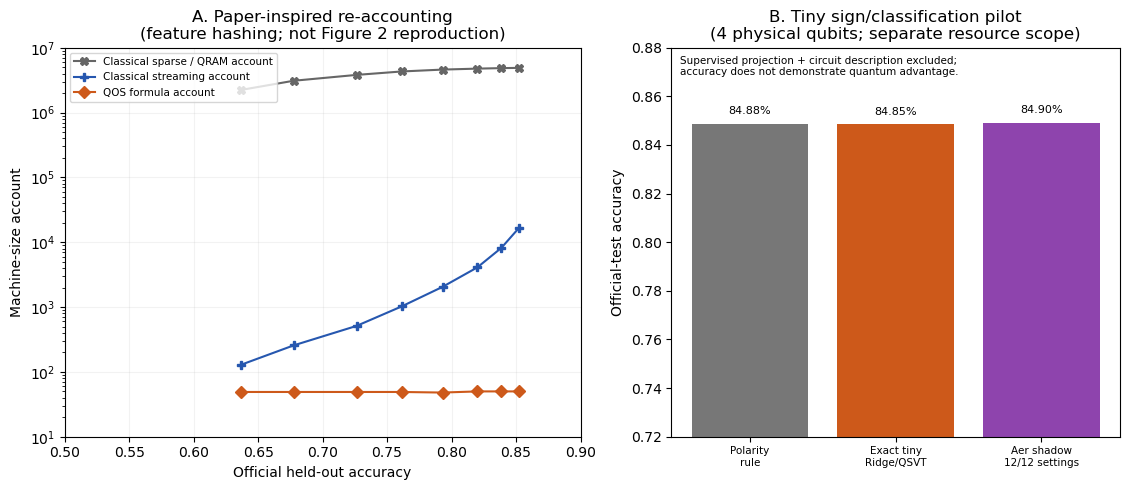

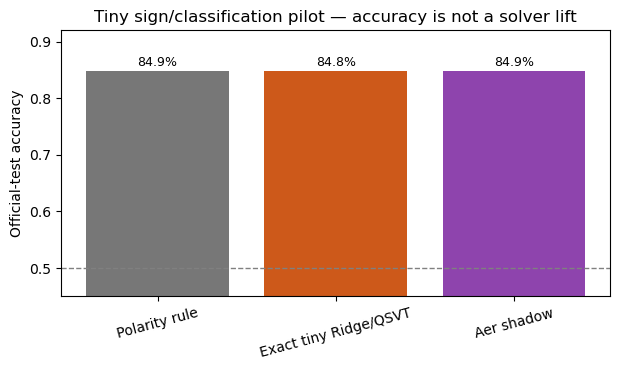

In [13]:
def load_hardware_shadow_summaries():
    if not HARDWARE_JSON_PATH.exists():
        return []
    rows = json.loads(HARDWARE_JSON_PATH.read_text(encoding="utf-8"))
    if not isinstance(rows, list):
        raise ValueError("hardware_results.json must contain a list.")
    requested_task_ids = {
        int(item) for item in HARDWARE_COHORT_TASK_IDS
    }
    trusted_rows = [
        row
        for row in rows
        if (
            row.get("fetch_reason") == "ok"
            and row.get("task_id_matches") is True
            and row.get("qasm_provenance_pass") is True
            and isinstance(row.get("counts_qiskit"), dict)
            and row.get("experiment_id") in entry_by_id
            and (
                not requested_task_ids
                or int(row.get("task_id", -1)) in requested_task_ids
            )
        )
    ]
    by_experiment = {}
    for row in trusted_rows:
        by_experiment.setdefault(row["experiment_id"], []).append(row)
    duplicates = {
        key: value
        for key, value in by_experiment.items()
        if len(value) > 1
    }
    if duplicates and not requested_task_ids:
        raise RuntimeError(
            "Multiple trusted hardware runs exist for the same "
            "experiment. Set HARDWARE_COHORT_TASK_IDS explicitly."
        )

    summaries = []
    for family in [
        "interferometric_shadow_control",
        "interferometric_shadow_qsvt",
    ]:
        family_rows = [
            row for row in trusted_rows if row.get("family") == family
        ]
        signatures = {
            canonical_json_hash(
                {
                    "backend": row.get("backend"),
                    "compiler": row.get("compiler"),
                    "target_qubits": row.get("target_qubits", []),
                }
            )
            for row in family_rows
        }
        if len(signatures) > 1:
            raise RuntimeError(
                f"{family} mixes backend/compiler/layout cohorts."
            )
        if not family_rows:
            continue
        signature_row = family_rows[0]
        matching_calibrations = {
            row.get("experiment_id")
            for row in trusted_rows
            if (
                row.get("family") == "calibration"
                and row.get(
                    "calibration_dominant_matches_expected"
                ) is True
                and row.get("backend") == signature_row.get("backend")
                and row.get("compiler") == signature_row.get("compiler")
                and row.get("target_qubits", [])
                == signature_row.get("target_qubits", [])
            )
        }
        required_calibrations = {
            f"tiny_cal_4q_x_q{qubit}" for qubit in range(4)
        }
        if matching_calibrations != required_calibrations:
            print(
                f"{family}: hardware summary withheld until all four "
                "coherent bit-order calibrations pass."
            )
            continue
        available = {
            row["experiment_id"]: row["counts_qiskit"]
            for row in family_rows
        }
        required_family_ids = {
            entry["experiment_id"]
            for entry in manifest_entries
            if entry["family"] == family
        }
        family_row_ids = [
            row["experiment_id"] for row in family_rows
        ]
        exactly_one_per_setting = bool(
            len(family_row_ids) == len(required_family_ids)
            and set(family_row_ids) == required_family_ids
        )
        if len(available) >= 2:
            summary = evaluate_shadow_collection(
                available,
                family,
                seed=SHADOW_SEED + 991,
            )
            summary["backend"] = signature_row.get("backend")
            summary["compiler"] = signature_row.get("compiler")
            summary["target_qubits"] = signature_row.get(
                "target_qubits", []
            )
            summary["fixed_physical_layout"] = bool(
                len(summary["target_qubits"]) == 4
                and len(set(summary["target_qubits"])) == 4
                and all(
                    int(item) >= 0
                    for item in summary["target_qubits"]
                )
            )
            summary["exactly_one_per_setting"] = (
                exactly_one_per_setting
            )
            summary["explicit_task_cohort"] = bool(
                requested_task_ids
            )
            summary["manual_time_window_confirmation"] = bool(
                CONFIRM_COHERENT_HARDWARE_COHORT
                == "I_REVIEWED_TASK_TIME_WINDOW"
            )
            prerequisite_report = None
            if family == "interferometric_shadow_qsvt":
                prerequisite_report = prerequisite_quality_report(
                    trusted_rows,
                    {
                        "backend": summary["backend"],
                        "compiler": summary["compiler"],
                        "target_qubits": summary["target_qubits"],
                    },
                )
            summary["prerequisite_quality_report"] = (
                prerequisite_report
            )
            summary["final_hardware_point"] = bool(
                family == "interferometric_shadow_qsvt"
                and summary["complete_setting_set"]
                and summary["exactly_one_per_setting"]
                and summary["fixed_physical_layout"]
                and summary["explicit_task_cohort"]
                and summary["manual_time_window_confirmation"]
                and prerequisite_report is not None
                and prerequisite_report["quality_pass"]
            )
            summaries.append(summary)
    return summaries


hardware_shadow_summaries = load_hardware_shadow_summaries()
summary_by_family = {
    item["family"]: item for item in local_shadow_summaries
}
hardware_summary_by_family = {
    item["family"]: item for item in hardware_shadow_summaries
}

fig, (ax_account, ax_bridge) = plt.subplots(
    1,
    2,
    figsize=(11.4, 5.0),
    gridspec_kw={"width_ratios": [1.15, 1.0]},
)
accuracy = reference_curve["official_test_accuracy"]
ax_account.plot(
    accuracy,
    reference_curve["machine_size_sparse_train_nnz"],
    "X-",
    color="#666666",
    label="Classical sparse / QRAM account",
)
ax_account.plot(
    accuracy,
    reference_curve["machine_size_streaming_D"],
    "P-",
    color="#2657AF",
    label="Classical streaming account",
)
ax_account.plot(
    accuracy,
    reference_curve["machine_size_qos_logical_qubits_formula"],
    "D-",
    color="#CD591A",
    label="QOS formula account",
)

local_shadow = summary_by_family.get(
    "interferometric_shadow_qsvt"
)
hardware_shadow = hardware_summary_by_family.get(
    "interferometric_shadow_qsvt"
)
ax_account.set_yscale("log")
ax_account.set_xlim(0.50, 0.90)
ax_account.set_ylim(10, 1e7)
ax_account.set_xlabel("Official held-out accuracy")
ax_account.set_ylabel("Machine-size account")
ax_account.set_title(
    "A. Paper-inspired re-accounting\n"
    "(feature hashing; not Figure 2 reproduction)"
)
ax_account.grid(True, which="major", alpha=0.16)
ax_account.legend(fontsize=7.5, loc="upper left")

bridge_labels = ["Polarity\nrule", "Exact tiny\nRidge/QSVT"]
bridge_values = [
    polarity_baseline_test_accuracy,
    classical_test_accuracy,
]
bridge_colors = ["#777777", "#CD591A"]
if local_shadow:
    bridge_labels.append("Aer shadow\n12/12 settings")
    bridge_values.append(local_shadow["test_accuracy"])
    bridge_colors.append("#8E44AD")
if hardware_shadow:
    hardware_setting_count = int(
        hardware_shadow["distinct_clifford_settings"]
    )
    hardware_state = (
        "final"
        if hardware_shadow["final_hardware_point"]
        else "provisional"
    )
    bridge_labels.append(
        "Quafu shadow\n"
        f"{hardware_setting_count}/{N_SHADOW_SETTINGS} "
        f"{hardware_state}"
    )
    bridge_values.append(hardware_shadow["test_accuracy"])
    bridge_colors.append("#A43A3A")

bridge_x = np.arange(len(bridge_values))
bridge_bars = ax_bridge.bar(
    bridge_x,
    bridge_values,
    color=bridge_colors,
)
if hardware_shadow and hardware_shadow["final_hardware_point"]:
    interval = hardware_shadow[
        "test_accuracy_setting_bootstrap_interval95"
    ]
    if interval is not None:
        low, high = interval
        value = hardware_shadow["test_accuracy"]
        ax_bridge.errorbar(
            [bridge_x[-1]],
            [value],
            yerr=[[value - low], [high - value]],
            fmt="none",
            color="black",
            capsize=3,
            lw=1,
        )
elif hardware_shadow:
    bridge_bars[-1].set_hatch("//")
    bridge_bars[-1].set_alpha(0.65)
ax_bridge.axhline(0.5, color="0.5", lw=1, ls="--")
ax_bridge.set_ylim(0.72, 0.88)
ax_bridge.set_xticks(bridge_x, bridge_labels)
ax_bridge.set_ylabel("Official-test accuracy")
ax_bridge.set_title(
    "B. Tiny sign/classification pilot\n"
    "(4 physical qubits; separate resource scope)"
)
ax_bridge.tick_params(axis="x", labelsize=7.5)
for bar, value in zip(bridge_bars, bridge_values):
    ax_bridge.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.004,
        f"{value:.2%}",
        ha="center",
        fontsize=8,
    )
ax_bridge.text(
    0.02,
    0.98,
    "Supervised projection + circuit description excluded;\n"
    "accuracy does not demonstrate quantum advantage.",
    transform=ax_bridge.transAxes,
    fontsize=7.5,
    va="top",
    bbox={
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.86,
        "pad": 2,
    },
)
fig.tight_layout()
comparison_figure = (
    FIGURE_DIR / "tiny-ridge-machine-size-comparison.png"
)
fig.savefig(comparison_figure, dpi=180)
plt.show()

labels = ["Polarity rule", "Exact tiny Ridge/QSVT"]
values = [polarity_baseline_test_accuracy, classical_test_accuracy]
if local_shadow:
    labels.append("Aer shadow")
    values.append(local_shadow["test_accuracy"])
if hardware_shadow:
    labels.append(
        "Quafu shadow\n"
        f"{hardware_setting_count}/{N_SHADOW_SETTINGS} "
        f"{hardware_state}"
    )
    values.append(hardware_shadow["test_accuracy"])

fig, ax = plt.subplots(figsize=(6.3, 3.8))
bars = ax.bar(
    labels,
    values,
    color=["#777777", "#CD591A", "#8E44AD", "#A43A3A"][
        :len(values)
    ],
)
ax.axhline(0.5, color="0.5", lw=1, ls="--")
ax.set_ylim(0.45, 0.92)
ax.set_ylabel("Official-test accuracy")
ax.set_title(
    "Tiny sign/classification pilot — accuracy is not a solver lift"
)
ax.tick_params(axis="x", rotation=15)
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.008,
        f"{value:.1%}",
        ha="center",
        fontsize=9,
    )
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "tiny-ridge-shadow-accuracy.png",
    dpi=180,
)
plt.show()


## 8. 结论读取规则

一条完整证据链至少需要：

1. 4q one-hot calibration 的 dominant bitstring 与假设一致；
2. direct Ridge prepare/unprepare echo control 接近 `0000`；
3. QSVT verifier 在 `signal=0, real=0` 条件下有可辨认的 conditional
   fidelity；
4. `shadow_control` 能恢复正确权重方向和分类准确率；
5. `shadow_qsvt` 在相同 Clifford seeds、相近设备时间窗下仍能恢复方向；
6. raw JSON、returned QASM、编译后 CX/depth 和 accepted herald events 一起保存。

分类 accuracy 不是 solver 增益证据：简单的 polarity rule
$w\propto(1,-1)$ 在这个监督式二维投影上与 exact Ridge 几乎相同，甚至可能略高。
QSVT 的直接机制证据来自 heralding、target-inverse verifier 和 returned circuit，
不是 accuracy 超过这个经典规则。12-setting shadow 当前主要验证权重符号/分类
方向；完整 overlap 幅值误差必须另行报告。

只有第 1–5 项全部在真实设备上成立，才能称为：

> “Quafu-SQC 上的 tiny Ridge inverse-QSVT + interferometric-shadow
> end-to-end mechanism validation。”

仍然不能称为：

- 复现论文 Figure 2 的真机量子优势；
- scalable QOS data loading；
- IMDb 实例的指数空间优势证明；
- fault-tolerant logical-qubit experiment；
- amplitude amplification（当前仅做 postselection）；
- Lemma F.16 的大规模 observable-only / median-of-means 保证。

本 notebook 的价值是把原 Figure 2 中没有真正执行的 quantum solver 和 shadow
读出，第一次缩成可提交、可审计、可由 held-out classification 验证的真机闭环。
